# ¿Qué gráfico responde mejor a cada pregunta?
### Una guía práctica para elegir visualizaciones según lo que queremos entender

> **Sobre los datos.** Todos los datos de este cuaderno son **simulados**: se generan dentro del propio código con una semilla fija y no representan resultados de ninguna empresa real. Los patrones se diseñaron para ilustrar decisiones gráficas y no deben leerse como evidencia sobre el mundo real.

Elegir un gráfico no consiste en recordar qué tipo «va» con cada situación, sino en decidir qué comparación necesitamos que el lector haga sin esfuerzo. Este cuaderno recorre cinco tipos de pregunta —comparar categorías, seguir un cambio en el tiempo, conocer una distribución, relacionar dos variables y entender cómo se reparte un total— y, en cada una, dibuja los mismos datos con representaciones distintas para ver qué tarea facilita cada una y cuál deja más difícil.

Es la segunda de tres partes de una sección sobre percepción visual y elección de gráficos. La primera trata cómo interpretamos la información visual (atributos preatentivos y principios de Gestalt); la tercera, cómo dirigir la atención y reducir distracciones (jerarquía visual, contraste, simplificación y anotaciones). Aquí aparecen aspectos de percepción solo cuando ayudan a justificar una elección.

**Contenido**

- **Apertura:** primero la pregunta
- **1. Comparación:** diferencias entre categorías
- **2. Evolución:** cambios a lo largo del tiempo
- **3. Distribución:** lo que un resumen puede ocultar
- **4. Relación:** cómo varían dos variables juntas
- **5. Composición:** cómo se divide un total
- **6. Un mismo conjunto de datos, varias preguntas**
- **Cierre:** guía de consulta y fuentes

**Requisitos.** Python 3.9 o superior con `numpy`, `pandas`, `matplotlib` (3.7 o superior) y `seaborn` (0.13 o superior). No necesita archivos externos ni conexión a internet; ejecutado de arriba abajo tarda pocos segundos y funciona igual en Jupyter y en Google Colab.

## Preparación

La primera celda importa las librerías; la segunda concentra la configuración visual. Se aplican tres reglas: morado como color principal, celeste y rosa como colores secundarios y grises para los elementos de contexto; cada categoría conserva su color en todas las figuras (por ejemplo, «Cuenta de ahorros» es siempre rosa); y los números se muestran en formato español, con punto para los miles y coma para los decimales.

In [1]:
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, MultipleLocator
import seaborn as sns

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

In [2]:
# Paleta: morado como color principal, celeste y rosa como secundarios, grises de contexto.
PURPLE, PURPLE_L = "#6B3FA0", "#CDBBE8"
SKY, SKY_L = "#4DB2E6", "#B7E1F6"
PINK, PINK_L = "#D9457F", "#F6BBD2"
GRAY, GRAY_L, GRAY_XL = "#7C7C8A", "#C9C9D2", "#E8E8EE"
INK = "#1F1B2E"

sns.set_theme(
    style="white",
    rc={
        "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
        "font.family": "sans-serif", "font.sans-serif": ["DejaVu Sans"],
        "font.size": 11, "axes.titlesize": 12.5, "axes.titleweight": "bold",
        "axes.titlelocation": "left", "axes.titlepad": 10, "axes.labelsize": 11,
        "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
        "axes.edgecolor": "#B8B8C4", "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": False, "grid.color": GRAY_XL, "grid.linewidth": 0.9,
        "legend.frameon": False, "legend.fontsize": 10.5,
        "figure.dpi": 110, "savefig.dpi": 110,
    },
)

# Una categoría conserva su color en todas las figuras.
PRODUCTOS = ["Tarjeta de crédito", "Crédito de consumo", "Cuenta de ahorros", "Seguros"]
COL_PROD = dict(zip(PRODUCTOS, [PURPLE, SKY, PINK, GRAY]))
TXT_PROD = dict(zip(PRODUCTOS, ["white", INK, "white", "white"]))
COL_CANAL = {
    "Web": PURPLE, "Banca móvil": SKY, "Sucursal": PINK, "Call center": GRAY,
    "Referidos": PURPLE_L, "Redes sociales": SKY_L, "Alianzas comerciales": PINK_L,
    "Correo directo": "#4A4A58",
}
COL_AGENCIA = {"Agencia A": PURPLE, "Agencia B": PINK}
SEGMENTOS = ["Minorista", "Pyme", "Corporativo"]
COL_SEG = dict(zip(SEGMENTOS, [SKY, PINK, PURPLE]))
MARK_SEG = dict(zip(SEGMENTOS, ["o", "s", "^"]))

MESES = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]


def n_es(x, dec=0):
    """Número con formato en español: 12.345,6"""
    texto = f"{x:,.{dec}f}"
    return texto.replace(",", "X").replace(".", ",").replace("X", ".")


def pct_es(p, dec=1):
    """Proporción (0-1) expresada como porcentaje en español."""
    return f"{n_es(p * 100, dec)} %"


fmt_n = FuncFormatter(lambda v, _: n_es(v))
fmt_pct = FuncFormatter(lambda v, _: f"{n_es(v * 100)} %")
fmt_pct100 = FuncFormatter(lambda v, _: f"{n_es(v)} %")


def etiqueta_mes(d):
    return f"{MESES[d.month - 1]} {str(d.year)[2:]}"


def ejes_tiempo(ax, indice, cada=3):
    """Marcas del eje horizontal cada `cada` meses, con etiquetas en español."""
    marcas = indice[::cada]
    ax.set_xticks(marcas)
    ax.set_xticklabels([etiqueta_mes(d) for d in marcas])

## Datos simulados

Se trabaja con cinco conjuntos pequeños y coherentes entre sí. Cada uno tiene su propio generador aleatorio, derivado de una misma semilla (`SEED = 2024`), de modo que cambiar uno no altera los demás.

| Conjunto | Unidad de análisis | Variables (unidad) | Tamaño |
|---|---|---|---|
| `ops` | combinación de mes, canal y producto | `mes`, `canal` (8 categorías), `producto` (4), `solicitudes` y `conversiones` (conteos) | 768 filas: 24 meses × 8 canales × 4 productos |
| `web_diario` | día | `fecha`, `solicitudes` (conteo diario del canal Web) | 731 días; sus sumas mensuales son las solicitudes del canal Web en `ops` |
| `servicio` | atención en ventanilla | `agencia`, `espera_min` (minutos), `satisfaccion` (puntaje de 0 a 100) | 1.000 atenciones, 500 por agencia |
| `clientes` | cliente | `segmento`, `transacciones_mes` (transacciones por mes), `monto_mes` (soles por mes) | 3.000 clientes |
| `campanas` | semana | `inversion_miles` (miles de soles por semana), `solicitudes_digitales` (conteo semanal) | 104 semanas |

Una **solicitud** es un pedido de un producto realizado en un canal; una **conversión** es una solicitud que termina en un producto contratado.

**Conteos, proporciones y tasas.** Solicitudes y conversiones son conteos. La *tasa de conversión* es `conversiones ÷ solicitudes`, calculada siempre sobre el mismo canal y periodo que se muestran. La *participación* de un producto es su parte dividida entre el total de su grupo, de modo que las participaciones de un grupo suman 100 %. Cuando se combinan varios grupos o meses, primero se suman numeradores y denominadores y después se divide: promediar tasas daría el mismo peso a canales de tamaños muy distintos.

In [3]:
SEED = 2024

MESES_IDX = pd.date_range("2023-01-01", "2024-12-01", freq="MS")   # 24 meses
ESTACIONALIDAD = {1: 0.92, 2: 0.90, 3: 0.98, 4: 1.00, 5: 1.02, 6: 0.97,
                  7: 1.00, 8: 0.99, 9: 1.00, 10: 1.03, 11: 1.10, 12: 1.18}

# ---- Serie diaria de solicitudes en el canal Web (se agrega luego a meses) ----
rng_web = np.random.default_rng(SEED + 1)
fechas = pd.date_range("2023-01-01", "2024-12-31", freq="D")
dias = np.arange(len(fechas))
efecto_semana = np.array([1.15, 1.12, 1.08, 1.05, 1.00, 0.70, 0.60])    # lunes ... domingo
efecto_semana = efecto_semana / efecto_semana.mean()

lam = (100
       * np.exp(0.012 * dias / 30.4)                                     # crecimiento gradual
       * fechas.month.map(ESTACIONALIDAD).to_numpy()                     # estacionalidad mensual
       * efecto_semana[fechas.dayofweek]                                 # patrón semanal
       * np.where(fechas >= "2024-03-01", 1.35, 1.0)                     # cambio de nivel desde marzo de 2024
       * np.where((fechas >= "2023-10-09") & (fechas <= "2023-10-29"), 1.8, 1.0))  # ráfaga de tres semanas
web_diario = pd.DataFrame({"fecha": fechas, "solicitudes": rng_web.poisson(lam)})
web_mensual = web_diario.set_index("fecha")["solicitudes"].resample("MS").sum()

# ---- Operación comercial: canal x producto x mes ----
CANALES = {
    #                   volumen base, crecimiento mensual, tasa base, mezcla de productos solicitados
    "Sucursal":             dict(base=5200, g=-0.004, tasa=0.22, mix=[0.34, 0.30, 0.26, 0.10]),
    "Banca móvil":          dict(base=3000, g=0.030,  tasa=0.31, mix=[0.12, 0.20, 0.58, 0.10]),
    "Web":                  dict(base=None, g=None,   tasa=None, mix=[0.25, 0.35, 0.30, 0.10]),
    "Call center":          dict(base=1400, g=0.000,  tasa=0.19, mix=[0.33, 0.31, 0.25, 0.11]),
    "Referidos":            dict(base=650,  g=0.010,  tasa=0.47, mix=[0.40, 0.35, 0.15, 0.10]),
    "Redes sociales":       dict(base=2100, g=0.015,  tasa=0.09, mix=[0.28, 0.32, 0.34, 0.06]),
    "Alianzas comerciales": dict(base=1000, g=0.005,  tasa=0.21, mix=[0.20, 0.22, 0.18, 0.40]),
    "Correo directo":       dict(base=800,  g=-0.020, tasa=0.07, mix=[0.45, 0.40, 0.05, 0.10]),
}
MULT_TASA = np.array([0.85, 1.00, 1.25, 0.75])      # la conversión difiere por producto

rng_ops = np.random.default_rng(SEED + 2)
filas = []
for canal, c in CANALES.items():
    for i, mes in enumerate(MESES_IDX):
        if canal == "Web":
            solicitudes = int(web_mensual.loc[mes])
            tasa = 0.27 if mes < pd.Timestamp("2024-03-01") else 0.22
        else:
            media = c["base"] * (1 + c["g"]) ** i * ESTACIONALIDAD[mes.month] * rng_ops.lognormal(0, 0.03)
            solicitudes = int(rng_ops.poisson(media))
            tasa = c["tasa"]
        sol_prod = rng_ops.multinomial(solicitudes, c["mix"])
        conv_prod = rng_ops.binomial(sol_prod, np.clip(tasa * MULT_TASA, 0, 0.95))
        for prod, s, v in zip(PRODUCTOS, sol_prod, conv_prod):
            filas.append((mes, canal, prod, int(s), int(v)))

ops = pd.DataFrame(filas, columns=["mes", "canal", "producto", "solicitudes", "conversiones"])
print(f"ops: {len(ops)} filas = 24 meses x 8 canales x 4 productos")
ops.head(6)

ops: 768 filas = 24 meses x 8 canales x 4 productos


,mes,canal,producto,solicitudes,conversiones
0,2023-01-01,Sucursal,Tarjeta de crédito,1608,328
1,2023-01-01,Sucursal,Crédito de consumo,1381,293
2,2023-01-01,Sucursal,Cuenta de ahorros,1255,350
3,2023-01-01,Sucursal,Seguros,455,80
4,2023-02-01,Sucursal,Tarjeta de crédito,1581,306
5,2023-02-01,Sucursal,Crédito de consumo,1331,277


In [4]:
# ---- Servicio: una fila por atención en ventanilla ----
rng_srv = np.random.default_rng(SEED + 3)
N_ATENCIONES = 500
espera_a = np.clip(rng_srv.normal(12, 3, N_ATENCIONES), 3, None)          # simétrica y concentrada
sigma = 0.75
espera_b = rng_srv.lognormal(np.log(12.5) - sigma ** 2 / 2, sigma, N_ATENCIONES)   # asimétrica a la derecha
servicio = pd.DataFrame({
    "agencia": ["Agencia A"] * N_ATENCIONES + ["Agencia B"] * N_ATENCIONES,
    "espera_min": np.concatenate([espera_a, espera_b]),
})
servicio["satisfaccion"] = np.clip(95 - 1.4 * servicio["espera_min"] + rng_srv.normal(0, 7, len(servicio)), 0, 100)

# ---- Clientes: una fila por cliente ----
rng_cli = np.random.default_rng(SEED + 4)
def grupo(n, seg, x_media, x_sd, y_media, pendiente, y_sd):
    x = np.clip(rng_cli.normal(x_media, x_sd, n), 1, None)
    y = np.clip(y_media + pendiente * (x - x_media) + rng_cli.normal(0, y_sd, n), 50, None)
    return pd.DataFrame({"segmento": seg, "transacciones_mes": x, "monto_mes": y})

clientes = pd.concat([
    grupo(2000, "Minorista",   30, 7.0, 1200,  40, 250),
    grupo(750,  "Pyme",        18, 4.5, 3200, 110, 450),
    grupo(250,  "Corporativo",  9, 2.5, 6500, 260, 700),
], ignore_index=True)

# ---- Campañas: una fila por semana ----
rng_camp = np.random.default_rng(SEED + 5)
N_SEMANAS = 104
inversion = rng_camp.uniform(4, 60, N_SEMANAS)
campanas = pd.DataFrame({
    "inversion_miles": inversion,
    "solicitudes_digitales": 650 + 1700 * (1 - np.exp(-inversion / 22)) + rng_camp.normal(0, 120, N_SEMANAS),
})
print(len(servicio), "atenciones |", len(clientes), "clientes |", len(campanas), "semanas")

1000 atenciones | 3000 clientes | 104 semanas


## Apertura: primero la pregunta

Elegir un gráfico empieza antes de abrir la librería, por decidir qué queremos saber. Una tabla no contiene una sola respuesta: contiene muchas, según qué columnas se crucen, qué agregación se aplique y qué comparación se busque. La tabla `ops` (solicitudes y conversiones por mes, canal y producto) admite cinco preguntas de naturaleza distinta, y cada una exige un cálculo diferente antes de pensar en el gráfico.

In [5]:
por_canal_prod = ops.groupby("canal")["conversiones"].sum()
por_mes = ops.groupby("mes")["conversiones"].sum()
anual = ops.groupby(ops["mes"].dt.year)["conversiones"].sum()
por_canal_mes = ops.groupby(["canal", "mes"])[["solicitudes", "conversiones"]].sum()
tasa_canal_mes = por_canal_mes["conversiones"] / por_canal_mes["solicitudes"]
r_vol_tasa = np.corrcoef(por_canal_mes["solicitudes"], tasa_canal_mes)[0, 1]
mix_prod = ops.groupby("producto")["conversiones"].sum().pipe(lambda s: s / s.sum())

respuestas = pd.DataFrame({
    "Pregunta": [
        "¿Qué categoría tiene el mayor resultado?",
        "¿Cómo cambia el resultado en el tiempo?",
        "¿Qué tan variables son los resultados?",
        "¿Existe una asociación entre dos variables?",
        "¿Cómo se reparte un total?",
    ],
    "Cálculo sobre la tabla ops": [
        "conversiones totales por canal",
        "conversiones totales de 2024 frente a 2023",
        "conversiones totales de cada mes: mínimo y máximo",
        "correlación entre solicitudes y tasa en las 192 combinaciones canal-mes",
        "participación de cada producto en las conversiones",
    ],
    "Resultado": [
        f"{por_canal_prod.idxmax()}: {n_es(por_canal_prod.max())} conversiones",
        f"{n_es(anual[2023])} en 2023 y {n_es(anual[2024])} en 2024 ({n_es((anual[2024] / anual[2023] - 1) * 100, 1)} %)",
        f"de {n_es(por_mes.min())} ({etiqueta_mes(por_mes.idxmin())}) a {n_es(por_mes.max())} ({etiqueta_mes(por_mes.idxmax())})",
        f"r = {n_es(r_vol_tasa, 2)}",
        f"{mix_prod.idxmax()}: {pct_es(mix_prod.max())} del total",
    ],
})
respuestas

,Pregunta,Cálculo sobre la tabla ops,Resultado
0,¿Qué categoría tiene el mayor resultado?,conversiones totales por canal,Banca móvil: 36.064 conversiones
1,¿Cómo cambia el resultado en el tiempo?,conversiones totales de 2024 frente a 2023,"51.666 en 2023 y 61.391 en 2024 (18,8 %)"
2,¿Qué tan variables son los resultados?,conversiones totales de cada mes: mínimo y máximo,de 3.472 (feb 23) a 6.665 (dic 24)
3,¿Existe una asociación entre dos variables?,correlación entre solicitudes y tasa en las 19...,"r = 0,12"
4,¿Cómo se reparte un total?,participación de cada producto en las conversi...,"Cuenta de ahorros: 43,1 % del total"


Lo que cambia entre las cinco filas no es la tabla sino la pregunta, y cada pregunta le pide algo distinto al ojo: comparar longitudes entre categorías (Banca móvil, 36.064 conversiones), seguir una trayectoria (de 51.666 conversiones en 2023 a 61.391 en 2024, un aumento de 18,8 %), juzgar la variabilidad (los totales mensuales van de 3.472 a 6.665), detectar una asociación (r = 0,12) o estimar partes de un todo (43,1 % para Cuenta de ahorros). Ese r bajo mezcla las 192 combinaciones de canal y mes y no dice nada sobre la relación dentro de cada canal: es un ejemplo de por qué la pregunta debe estar clara antes de calcular.

La siguiente tabla relaciona cada intención analítica con una pregunta típica y con los gráficos que suelen responderla. Es un punto de partida, no una correspondencia rígida: la misma intención admite varios gráficos y, como se verá, la misma pregunta puede replantearse según el detalle que se necesite conservar.

| Intención analítica | Pregunta típica | Gráficos posibles | Sección |
|---|---|---|---|
| Comparar categorías | ¿Qué canal tiene más conversiones? | Barras horizontales ordenadas, barras verticales, gráfico de puntos | 1 |
| Seguir un cambio en el tiempo | ¿Cómo evolucionan las solicitudes mes a mes? | Líneas, barras temporales, líneas múltiples | 2 |
| Conocer una distribución | ¿Los tiempos de espera se concentran cerca del promedio? | Histograma, boxplot, puntos individuales | 3 |
| Ver la relación entre dos variables | ¿Los clientes con más transacciones mueven más dinero? | Dispersión, con color, transparencia o conteo por celdas | 4 |
| Entender cómo se reparte un total | ¿Cómo se divide el total de conversiones entre productos? | Barras al 100 %, barras apiladas, sectores con pocas categorías, barras simples | 5 |

## 1. Comparación: diferencias entre categorías

**Pregunta:** ¿qué canal aporta más conversiones entre enero de 2023 y diciembre de 2024?

La variable es `conversiones`, sumada por `canal` (ocho categorías, 24 meses cada una). Es una comparación entre categorías sin orden natural, así que el gráfico debe permitir ubicar el mayor y el menor y estimar cuántas veces uno supera a otro. Los tres paneles siguientes usan exactamente los mismos ocho valores y la misma escala; cambian la orientación, el orden y la marca visual.

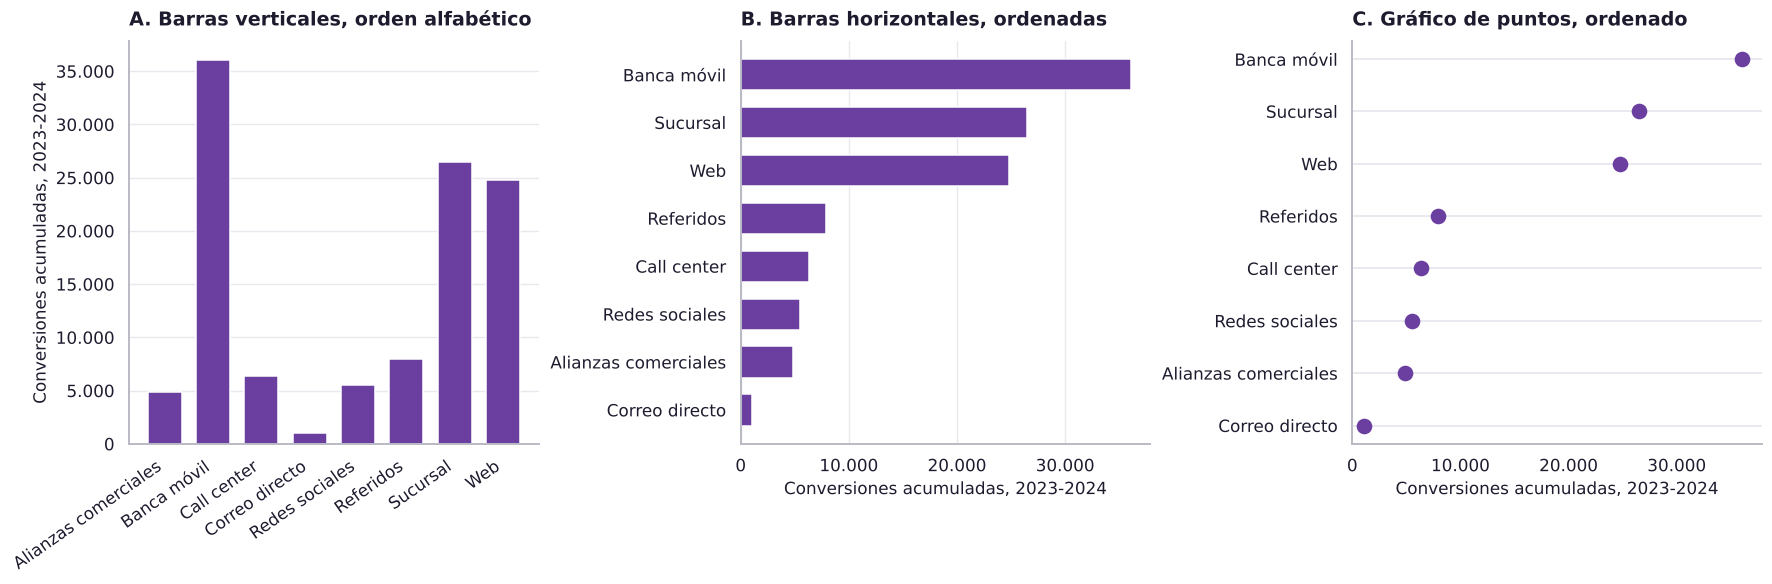

In [6]:
por_canal = (
    ops.groupby("canal")[["solicitudes", "conversiones"]].sum()
    .assign(tasa=lambda d: d["conversiones"] / d["solicitudes"])
)
conv = por_canal["conversiones"]
alfabetico = conv.sort_index()
descendente = conv.sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), layout="constrained")

# A. Barras verticales, orden alfabético (el orden por defecto de muchas tablas)
ax = axes[0]
ax.bar(alfabetico.index, alfabetico.values, color=PURPLE, width=0.7)
ax.set_title("A. Barras verticales, orden alfabético")
ax.tick_params(axis="x", rotation=35)
for etiqueta in ax.get_xticklabels():
    etiqueta.set_ha("right")
ax.yaxis.grid(True)

# B. Barras horizontales ordenadas de mayor a menor
ax = axes[1]
ax.barh(descendente.index[::-1], descendente.values[::-1], color=PURPLE, height=0.65)
ax.set_title("B. Barras horizontales, ordenadas")
ax.xaxis.grid(True)

# C. Gráfico de puntos con el mismo orden
ax = axes[2]
posiciones = np.arange(len(descendente))
ax.hlines(posiciones, 0, descendente.values[::-1].max() * 1.05, color=GRAY_XL, lw=1.2)
ax.scatter(descendente.values[::-1], posiciones, s=85, color=PURPLE, zorder=3)
ax.set_yticks(posiciones)
ax.set_yticklabels(descendente.index[::-1])
ax.set_title("C. Gráfico de puntos, ordenado")

tope = descendente.max() * 1.05
for ax in axes:
    ax.set_axisbelow(True)
axes[0].set_ylim(0, tope)
axes[0].set_ylabel("Conversiones acumuladas, 2023-2024")
for ax in axes[1:]:
    ax.set_xlim(0, tope)
    ax.xaxis.set_major_locator(MultipleLocator(10000))
    ax.set_xlabel("Conversiones acumuladas, 2023-2024")
for ax in axes:
    (ax.yaxis if ax is axes[0] else ax.xaxis).set_major_formatter(fmt_n)
plt.show()

Entre los paneles hay dos diferencias que conviene separar. La primera es de orientación. Los nombres de los canales llegan a veinte caracteres («Alianzas comerciales»): en barras verticales hay que inclinarlos para que quepan, mientras que en horizontal se leen de izquierda a derecha sin esfuerzo. Con tres o cuatro categorías de nombre corto, las barras verticales son igual de legibles; con ocho nombres largos, o con más categorías, la orientación horizontal resulta más cómoda.

La segunda diferencia es el orden. El panel A conserva el orden alfabético, el que suele traer una tabla, y obliga a recorrer las barras para ubicar el máximo. En B y C, ordenar por valor deja a Banca móvil (36.064 conversiones) arriba y a Correo directo (1.062) abajo, y la posición de cada canal intermedio queda a la vista. Ordenar tiene sentido cuando las categorías no tienen un orden propio; si fueran tramos de edad o meses, el orden natural prevalece.

Cada marca aporta algo distinto. Las barras codifican el valor con su longitud a partir de un cero visible, y por eso dan una idea inmediata de cuántas veces es mayor una categoría que otra. El gráfico de puntos codifica con la posición sobre una escala común, una de las estimaciones visuales más precisas según los experimentos de Cleveland y McGill [1], y ocupa menos tinta: es útil cuando hay muchas categorías o cuando las diferencias relevantes son pequeñas respecto del total, porque admite un eje que no parte de cero (aquí se mantuvo en cero para que los tres paneles sean equivalentes). A cambio, transmite menos la sensación de cantidad acumulada que una barra.

In [7]:
primero, segundo = descendente.iloc[0], descendente.iloc[1]
corte = np.floor(0.8 * segundo / 1000) * 1000      # un eje que arranca cerca de los valores

print(f"{descendente.index[0]}: {n_es(primero)} conversiones | {descendente.index[1]}: {n_es(segundo)} conversiones")
print(f"Razón real entre ambos canales: {n_es(primero / segundo, 2)}")
print(f"Si el eje empezara en {n_es(corte)}, la barra de {descendente.index[0]} mediría "
      f"{n_es((primero - corte) / (segundo - corte), 2)} veces la de {descendente.index[1]}")

Banca móvil: 36.064 conversiones | Sucursal: 26.492 conversiones
Razón real entre ambos canales: 1,36
Si el eje empezara en 21.000, la barra de Banca móvil mediría 2,74 veces la de Sucursal


**Por qué las barras deben partir de cero.** En una barra, la longitud *es* el dato, y el lector interpreta la razón entre longitudes como la razón entre valores. Banca móvil tiene 1,36 veces las conversiones de Sucursal; si el eje arrancara en 21.000, su barra mediría 2,74 veces la de Sucursal. Los datos no cambian, pero la comparación visual sí. La regla vale para barras y áreas; en un gráfico de puntos o de líneas la información está en la posición, y un eje que no parte de cero es admisible siempre que se vea con claridad.

**Pregunta:** ¿qué canal convierte mejor sus solicitudes?

Contar conversiones y medir la eficacia para convertir no es lo mismo. La tasa de conversión divide las conversiones de cada canal entre sus propias solicitudes. El panel izquierdo repite el conteo anterior y el derecho muestra la tasa.

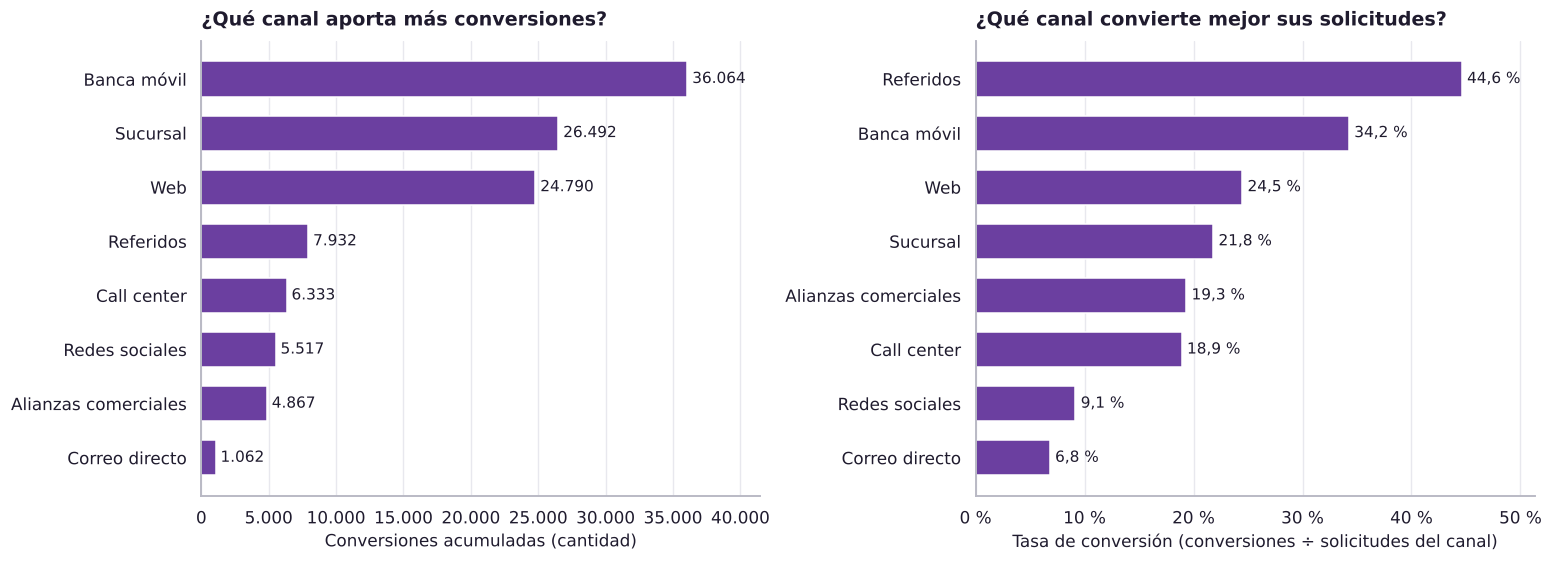

In [8]:
conv_orden = por_canal.sort_values("conversiones", ascending=False)
tasa_orden = por_canal.sort_values("tasa", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), layout="constrained")

ax = axes[0]
ax.barh(conv_orden.index[::-1], conv_orden["conversiones"][::-1], color=PURPLE, height=0.65)
for y, v in enumerate(conv_orden["conversiones"][::-1]):
    ax.text(v + conv_orden["conversiones"].max() * 0.01, y, n_es(v), va="center", fontsize=10)
ax.set_xlim(0, conv_orden["conversiones"].max() * 1.15)
ax.xaxis.set_major_formatter(fmt_n)
ax.set_xlabel("Conversiones acumuladas (cantidad)")
ax.set_title("¿Qué canal aporta más conversiones?")

ax = axes[1]
ax.barh(tasa_orden.index[::-1], tasa_orden["tasa"][::-1], color=PURPLE, height=0.65)
for y, v in enumerate(tasa_orden["tasa"][::-1]):
    ax.text(v + 0.005, y, pct_es(v), va="center", fontsize=10)
ax.set_xlim(0, tasa_orden["tasa"].max() * 1.15)
ax.xaxis.set_major_formatter(fmt_pct)
ax.set_xlabel("Tasa de conversión (conversiones ÷ solicitudes del canal)")
ax.set_title("¿Qué canal convierte mejor sus solicitudes?")

for ax in axes:
    ax.xaxis.grid(True)
    ax.set_axisbelow(True)
plt.show()

El canal con más conversiones, Banca móvil, es el segundo en tasa (34,2 %); el de mayor tasa, Referidos (44,6 %), queda cuarto en conversiones: recibió solo 17.784 solicitudes y produjo 7.932 conversiones. No hay contradicción, hay dos preguntas. El conteo dimensiona el aporte de cada canal al resultado total y sirve para planificar capacidad o presupuesto; la tasa compara qué tan bien aprovecha cada canal las oportunidades que recibe, con independencia de su tamaño, y sirve para evaluar eficacia. Otros dos canales lo ilustran: Sucursal recibe más solicitudes que ninguno (121.573) pero las convierte al 21,8 %, y Redes sociales recibe 60.307 con una tasa de 9,1 %, lo que la deja sexta en conversiones.

In [9]:
tabla_canales = pd.DataFrame({
    "Solicitudes": por_canal["solicitudes"].map(n_es),
    "Conversiones": por_canal["conversiones"].map(n_es),
    "Tasa de conversión": por_canal["tasa"].map(pct_es),
    "Puesto por conversiones": por_canal["conversiones"].rank(ascending=False).astype(int),
    "Puesto por tasa": por_canal["tasa"].rank(ascending=False).astype(int),
}).loc[conv_orden.index]
tabla_canales

,Solicitudes,Conversiones,Tasa de conversión,Puesto por conversiones,Puesto por tasa
canal,,,,,
Banca móvil,105.297,36.064,"34,2 %",1,2
Sucursal,121.573,26.492,"21,8 %",2,4
Web,101.372,24.790,"24,5 %",3,3
Referidos,17.784,7.932,"44,6 %",4,1
Call center,33.505,6.333,"18,9 %",5,6
Redes sociales,60.307,5.517,"9,1 %",6,7
Alianzas comerciales,25.193,4.867,"19,3 %",7,5
Correo directo,15.628,1.062,"6,8 %",8,8


Una limitación al comparar tasas es que no dicen cuántas observaciones hay detrás. Una tasa alta calculada sobre pocas solicitudes es más inestable que una calculada sobre muchas; cuando la decisión depende de la tasa, conviene mostrar también el denominador, como se hace en la sección 6.

## 2. Evolución: cambios a lo largo del tiempo

**Pregunta:** ¿cómo evolucionaron las solicitudes mensuales del canal Web entre enero de 2023 y diciembre de 2024?

La serie tiene 24 observaciones mensuales (la suma de la serie diaria `web_diario`) y reúne cuatro rasgos de diseño que interesa poder reconocer: una tendencia creciente, un pico aislado en octubre de 2023, un repunte estacional en diciembre y un cambio de nivel a partir de marzo de 2024. Los dos paneles muestran los mismos valores, con el eje vertical desde cero en ambos.

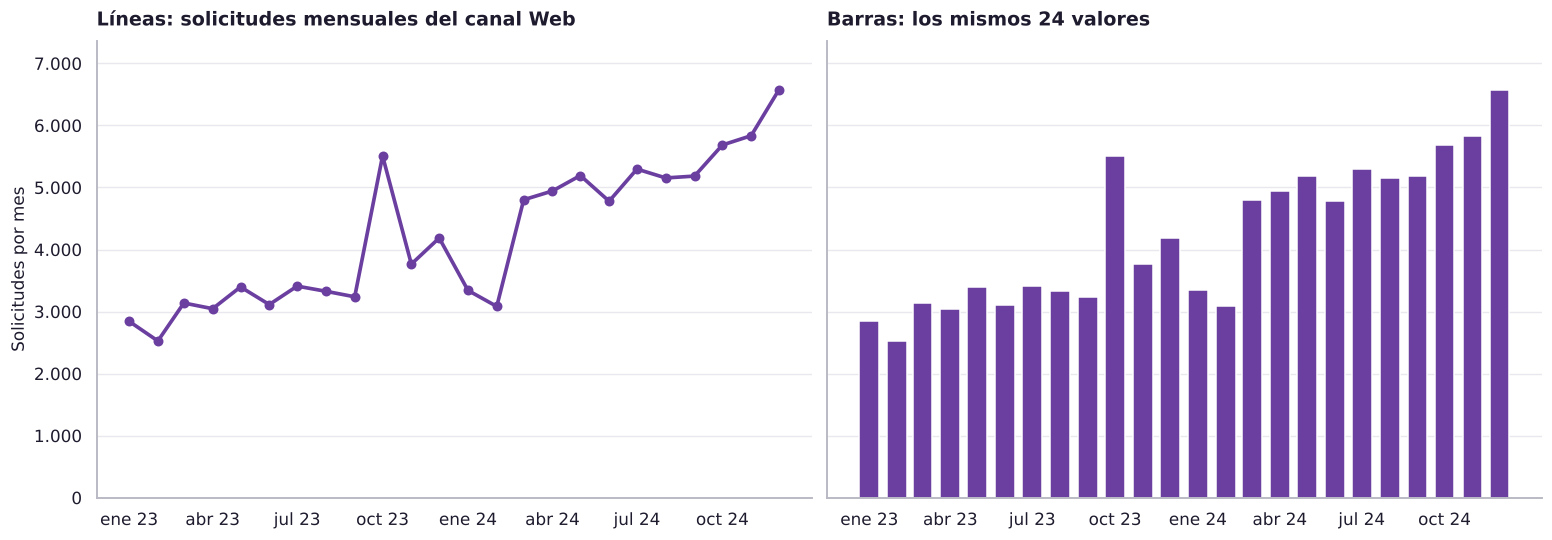

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True, layout="constrained")

ax = axes[0]
ax.plot(web_mensual.index, web_mensual.values, color=PURPLE, lw=2.4, marker="o", ms=5.5)
ax.set_title("Líneas: solicitudes mensuales del canal Web")

ax = axes[1]
ax.bar(web_mensual.index, web_mensual.values, width=22, color=PURPLE)
ax.set_title("Barras: los mismos 24 valores")

for ax in axes:
    ax.set_ylim(0, web_mensual.max() * 1.12)
    ejes_tiempo(ax, web_mensual.index)
    ax.yaxis.set_major_formatter(fmt_n)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
axes[0].set_ylabel("Solicitudes por mes")
plt.show()

La línea conecta cada mes con el siguiente, de modo que la pendiente de cada tramo comunica el ritmo de cambio: el salto de 3.083 solicitudes en febrero de 2024 a 4.802 en marzo se ve como un tramo casi vertical. También se distingue el pico de octubre de 2023 (5.509, frente a 3.238 en septiembre y 3.765 en noviembre) y el repunte de diciembre (4.186 en diciembre de 2023 contra 3.341 en enero de 2024). Antes de marzo de 2024, solo octubre de 2023 superó las 4.200 solicitudes; desde marzo, ningún mes baja de 4.779. Eso es un cambio de nivel, y no un pico ni una oscilación estacional, y se reconoce con claridad en ambos gráficos.

Las barras, en cambio, facilitan comparar el valor de dos meses concretos —por ejemplo, diciembre de 2024 (6.577) con enero de 2023 (2.843)— y recuerdan que cada valor es una cantidad acumulada en un periodo. A cambio, seguir la trayectoria obliga al ojo a comparar alturas contiguas. Con 24 barras funciona bien; con series mucho más largas las barras se convierten en un muro de rectángulos y la línea gana.

**Orden y continuidad.** El eje horizontal respeta el orden cronológico y el espaciado uniforme: reordenar los meses por valor, como se hizo con los canales, destruiría justamente lo que se quiere ver, que es la secuencia. Además, una línea afirma algo: que existe un valor entre dos observaciones y que el fenómeno varía de forma continua. Para totales mensuales es una convención aceptable, aunque cada punto es un acumulado de periodo y no una medición instantánea (de ahí que las barras también sean razonables). Para categorías sin orden, como los canales, unir puntos sugeriría una trayectoria que no existe.

**Pregunta:** ¿los tres canales con más solicitudes siguen trayectorias parecidas?

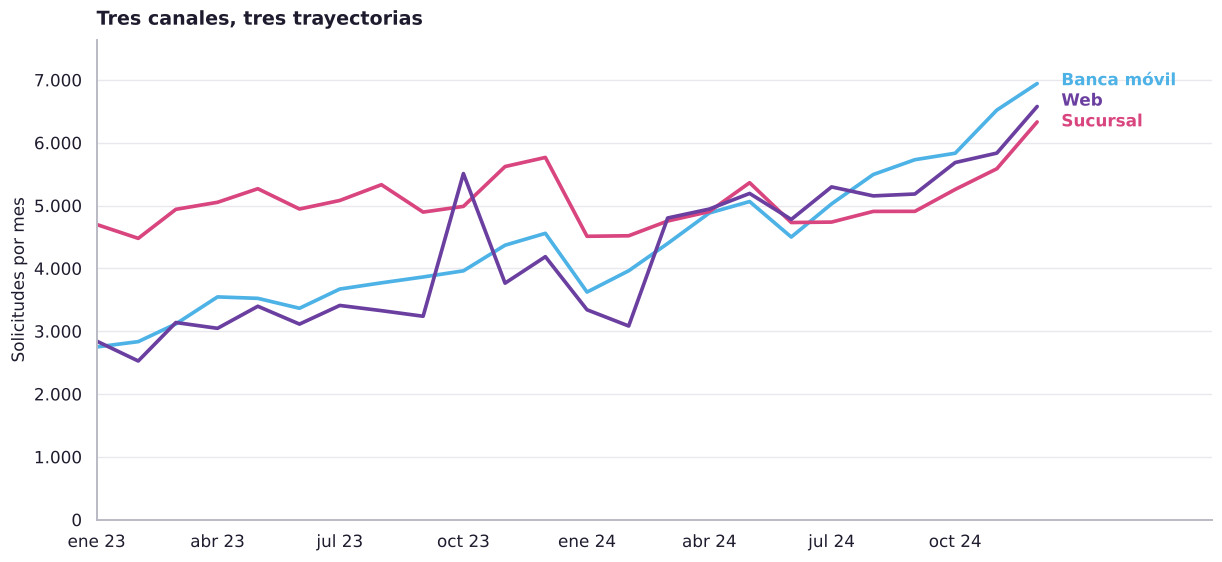

Banca móvil supera por primera vez a Sucursal en jul 24.


In [11]:
sol_mes = ops.pivot_table(index="mes", columns="canal", values="solicitudes", aggfunc="sum")
trayectorias = ["Banca móvil", "Sucursal", "Web"]

# Posición de las etiquetas finales: se separan para que no se superpongan.
finales = sol_mes[trayectorias].iloc[-1].sort_values()
y_etiqueta, previo = {}, -np.inf
for canal, valor in finales.items():
    previo = max(valor, previo + 330)
    y_etiqueta[canal] = previo

fig, ax = plt.subplots(figsize=(11, 5), layout="constrained")
for canal in trayectorias:
    ax.plot(sol_mes.index, sol_mes[canal], color=COL_CANAL[canal], lw=2.4)
    ax.text(sol_mes.index[-1] + pd.Timedelta(days=18), y_etiqueta[canal], canal,
            color=COL_CANAL[canal], va="center", fontsize=11, fontweight="bold")
ax.set_xlim(sol_mes.index[0], sol_mes.index[-1] + pd.Timedelta(days=130))
ax.set_ylim(0, sol_mes[trayectorias].to_numpy().max() * 1.1)
ejes_tiempo(ax, sol_mes.index)
ax.yaxis.set_major_formatter(fmt_n)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.set_ylabel("Solicitudes por mes")
ax.set_title("Tres canales, tres trayectorias")
plt.show()

cruce = (sol_mes["Banca móvil"] > sol_mes["Sucursal"]).idxmax()
print(f"Banca móvil supera por primera vez a Sucursal en {etiqueta_mes(cruce)}.")

Las series comparten escala y comparten el mismo código de color con el que cada canal aparece en otras figuras. Banca móvil crece de 2.749 solicitudes en enero de 2023 a 6.942 en diciembre de 2024 y supera a Sucursal desde julio de 2024, manteniéndose por encima hasta el final. Sucursal se mueve entre 4.478 y 6.331 sin una tendencia clara. Como todos los canales comparten la estacionalidad, la comparación más limpia es diciembre contra diciembre: Web crece 57 % (de 4.186 a 6.577), Banca móvil 52 % (de 4.558 a 6.942) y Sucursal 10 % (de 5.766 a 6.331).

Tres líneas superpuestas son cercanas al límite de lo cómodo, y las etiquetas directas al final de cada trazo evitan ir y venir a una leyenda. Con más series conviene pasar a paneles pequeños con la misma escala vertical, y si lo que interesa es el ritmo de crecimiento y no el nivel, un índice con base 100 en el primer mes pone a todas en el mismo punto de partida.

**Periodos sin datos.** En el siguiente ejemplo se supone que el sistema que registra las solicitudes del Call center no guardó información en septiembre y octubre de 2023. El panel izquierdo trata esos meses como datos faltantes; el derecho los reemplaza por cero.

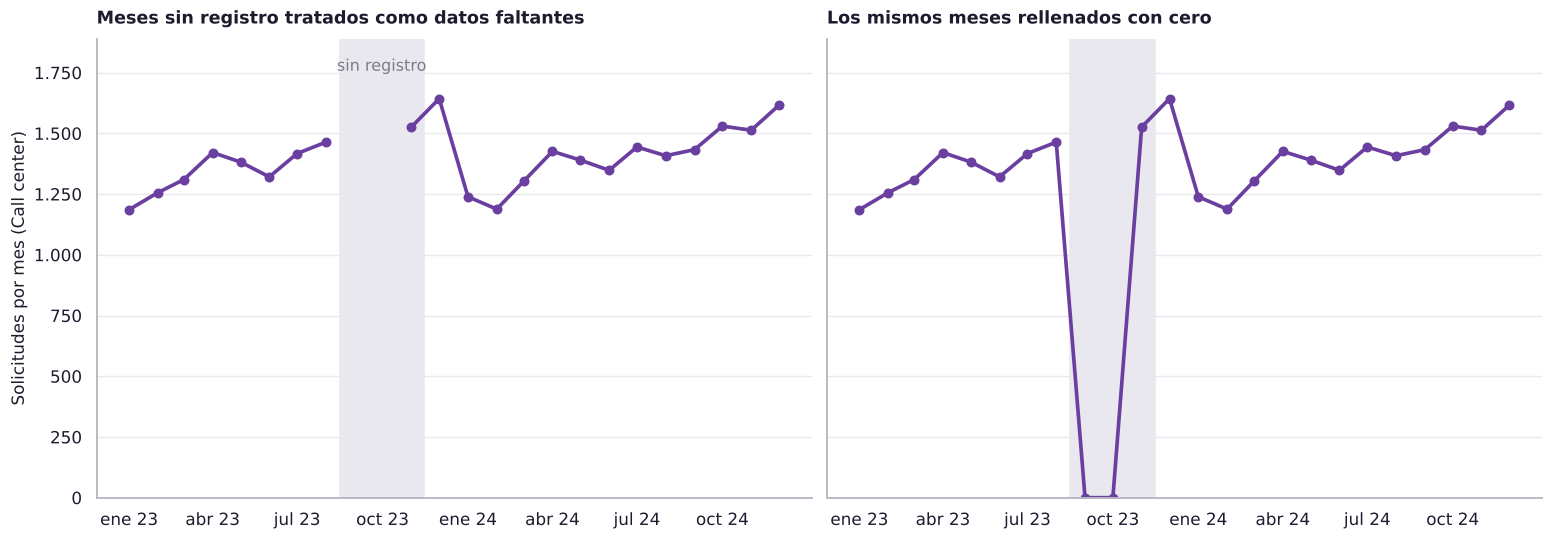

Promedio mensual de los demás meses: 1.398


In [12]:
# Supuesto ilustrativo: el sistema de registro del Call center no guardó dos meses.
call_center = sol_mes["Call center"].copy()
sin_dato = call_center.copy()
sin_dato.loc[["2023-09-01", "2023-10-01"]] = np.nan
rellenado_con_cero = sin_dato.fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True, layout="constrained")
for ax, serie, titulo in [
    (axes[0], sin_dato, "Meses sin registro tratados como datos faltantes"),
    (axes[1], rellenado_con_cero, "Los mismos meses rellenados con cero"),
]:
    ax.axvspan(pd.Timestamp("2023-08-16"), pd.Timestamp("2023-11-15"), color=GRAY_XL, zorder=0)
    ax.plot(serie.index, serie.values, color=PURPLE, lw=2.4, marker="o", ms=5.5)
    ax.set_title(titulo, fontsize=11.5)
    ejes_tiempo(ax, serie.index)
    ax.yaxis.set_major_formatter(fmt_n)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
axes[0].set_ylim(0, call_center.max() * 1.15)
axes[0].set_ylabel("Solicitudes por mes (Call center)")
axes[0].text(pd.Timestamp("2023-09-30"), call_center.max() * 1.07, "sin registro", ha="center", color=GRAY, fontsize=10.5)
plt.show()

print("Promedio mensual de los demás meses:", n_es(sin_dato.mean()))

En la versión de la izquierda la línea se interrumpe donde no hay registro y la franja gris lo señala. En la de la derecha, el relleno con cero produce una caída a cero y una recuperación inmediata, que sugiere que el canal dejó de recibir solicitudes. En esta simulación los dos meses sí tuvieron actividad (1.362 y 1.379 solicitudes, en línea con el promedio de 1.398 de los demás meses), pero la serie «registrada» no lo refleja. Cero es un valor —significa que se observó que no hubo eventos—, mientras que un dato faltante significa que no se observó nada; confundirlos distorsiona tendencias, promedios y tasas. Las alternativas son dejar el hueco y anotarlo, estimar los valores con un método declarado y distinguirlos visualmente (por ejemplo, con una línea punteada), o limitar el análisis a los periodos con datos.

**Detalle y agregación.** La misma información puede mirarse con distinta frecuencia. La siguiente figura parte de la serie diaria de solicitudes Web y la expresa en una unidad común —solicitudes por día en promedio— para que ambos paneles sean comparables en altura; sumar por mes mezclaría la actividad con la duración del mes, que va de 28 a 31 días.

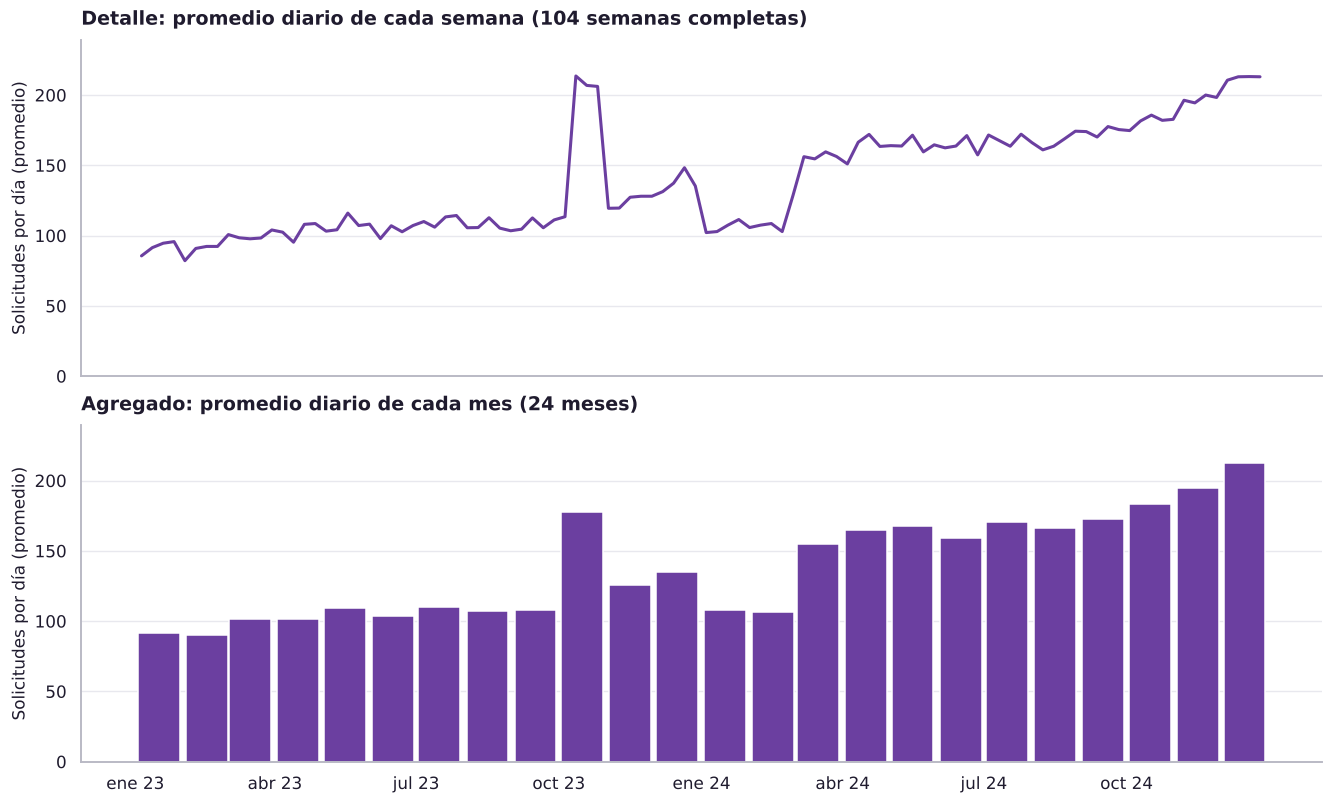

Pico semanal en octubre de 2023: 214 solicitudes por día (promedio de las 8 semanas previas: 109)
Promedio diario mensual: septiembre de 2023 = 108, octubre de 2023 = 178
Promedio diario trimestral: 3T 2023 = 108, 4T 2023 = 146


In [13]:
serie_diaria = web_diario.set_index("fecha")["solicitudes"]

semanas = serie_diaria.resample("W-SUN")
semanal = semanas.mean()[semanas.count() == 7]          # solo semanas completas
semanal.index = semanal.index - pd.Timedelta(days=3)    # etiqueta en el centro de la semana
mensual = serie_diaria.resample("MS").mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 7.2), sharex=True, sharey=True, layout="constrained")

ax = axes[0]
ax.plot(semanal.index, semanal.values, color=PURPLE, lw=2)
ax.set_title(f"Detalle: promedio diario de cada semana ({len(semanal)} semanas completas)")

ax = axes[1]
ax.bar(mensual.index + pd.Timedelta(days=15), mensual.values, width=27, color=PURPLE)
ax.set_title("Agregado: promedio diario de cada mes (24 meses)")

for ax in axes:
    ax.set_ylim(0, semanal.max() * 1.12)
    ax.set_ylabel("Solicitudes por día (promedio)")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
ejes_tiempo(axes[1], mensual.index)
plt.show()

trimestral = serie_diaria.resample("QS").mean()
print(f"Pico semanal en octubre de 2023: {n_es(semanal['2023-10'].max())} solicitudes por día "
      f"(promedio de las 8 semanas previas: {n_es(semanal['2023-08-14':'2023-10-08'].mean())})")
print(f"Promedio diario mensual: septiembre de 2023 = {n_es(mensual['2023-09-01'])}, octubre de 2023 = {n_es(mensual['2023-10-01'])}")
print(f"Promedio diario trimestral: 3T 2023 = {n_es(trimestral['2023-07-01'])}, 4T 2023 = {n_es(trimestral['2023-10-01'])}")

En el detalle semanal, la ráfaga de octubre de 2023 alcanza 214 solicitudes por día, casi el doble de las 109 que promedian las ocho semanas previas, y se reconoce como un episodio de unas tres semanas. En el promedio mensual esa misma ráfaga se diluye en un octubre de 178 solicitudes por día (unos dos tercios más que septiembre, con 108) y se lee como un mes alto, no como un episodio acotado. Con trimestres sería aún menos reconocible: el cuarto trimestre de 2023 promedia 146 por día, alrededor de un tercio más que el tercero (108), y mezcla la ráfaga con el repunte de fin de año.

Al agregar se pierden la duración y las fechas de inicio y fin de los episodios, el patrón semanal y la rapidez de los cambios. No es una pérdida sin contrapartida: la vista mensual reduce el ruido y resulta adecuada para tendencias y reportes periódicos, mientras que la semanal sirve para localizar eventos. La frecuencia correcta depende de la escala de tiempo en la que ocurre aquello que se quiere detectar.

## 3. Distribución: lo que un resumen puede ocultar

**Pregunta:** ¿los tiempos de espera de una agencia se concentran cerca del promedio?

El conjunto `servicio` tiene 500 atenciones por agencia, con el tiempo de espera en minutos. Las dos agencias tienen una espera media casi idéntica, y una comparación basada solo en promedios concluiría que ofrecen un servicio equivalente. El resumen numérico ya sugiere otra cosa.

In [14]:
def limites_tukey(x):
    q1, q3 = np.percentile(x, [25, 75])
    riq = q3 - q1
    return q1 - 1.5 * riq, q3 + 1.5 * riq


AGENCIAS = ["Agencia A", "Agencia B"]
esperas = {a: servicio.loc[servicio["agencia"] == a, "espera_min"] for a in AGENCIAS}

resumen = pd.DataFrame({
    a: {
        "Atenciones": len(x),
        "Media (min)": x.mean(),
        "Mediana (min)": x.median(),
        "Desviación estándar (min)": x.std(),
        "Percentil 25 (min)": x.quantile(0.25),
        "Percentil 75 (min)": x.quantile(0.75),
        "Percentil 95 (min)": x.quantile(0.95),
        "Máximo (min)": x.max(),
        "Fuera de los bigotes": int(((x < limites_tukey(x)[0]) | (x > limites_tukey(x)[1])).sum()),
    }
    for a, x in esperas.items()
})
resumen.round(1)

,Agencia A,Agencia B
Atenciones,500.0,500.0
Media (min),12.1,12.7
Mediana (min),12.2,9.0
Desviación estándar (min),3.2,11.5
Percentil 25 (min),10.1,5.5
Percentil 75 (min),14.4,15.2
Percentil 95 (min),17.0,36.7
Máximo (min),21.0,74.8
Fuera de los bigotes,4.0,41.0


Las medias son 12,1 y 12,7 minutos, pero la desviación estándar es 3,2 minutos en la Agencia A y 11,5 en la B. La mediana de B (9,0) queda 3,7 minutos por debajo de su media, y su percentil 95 es 36,7 minutos frente a 17,0 en A. Para ver qué ocurre entre esos números hace falta mirar la forma. La figura siguiente combina, con el mismo eje horizontal, un histograma por agencia y un diagrama de caja de las dos. Los histogramas usan los mismos intervalos (2,5 minutos) y la misma escala vertical, y como ambas agencias tienen 500 atenciones, las alturas son directamente comparables.

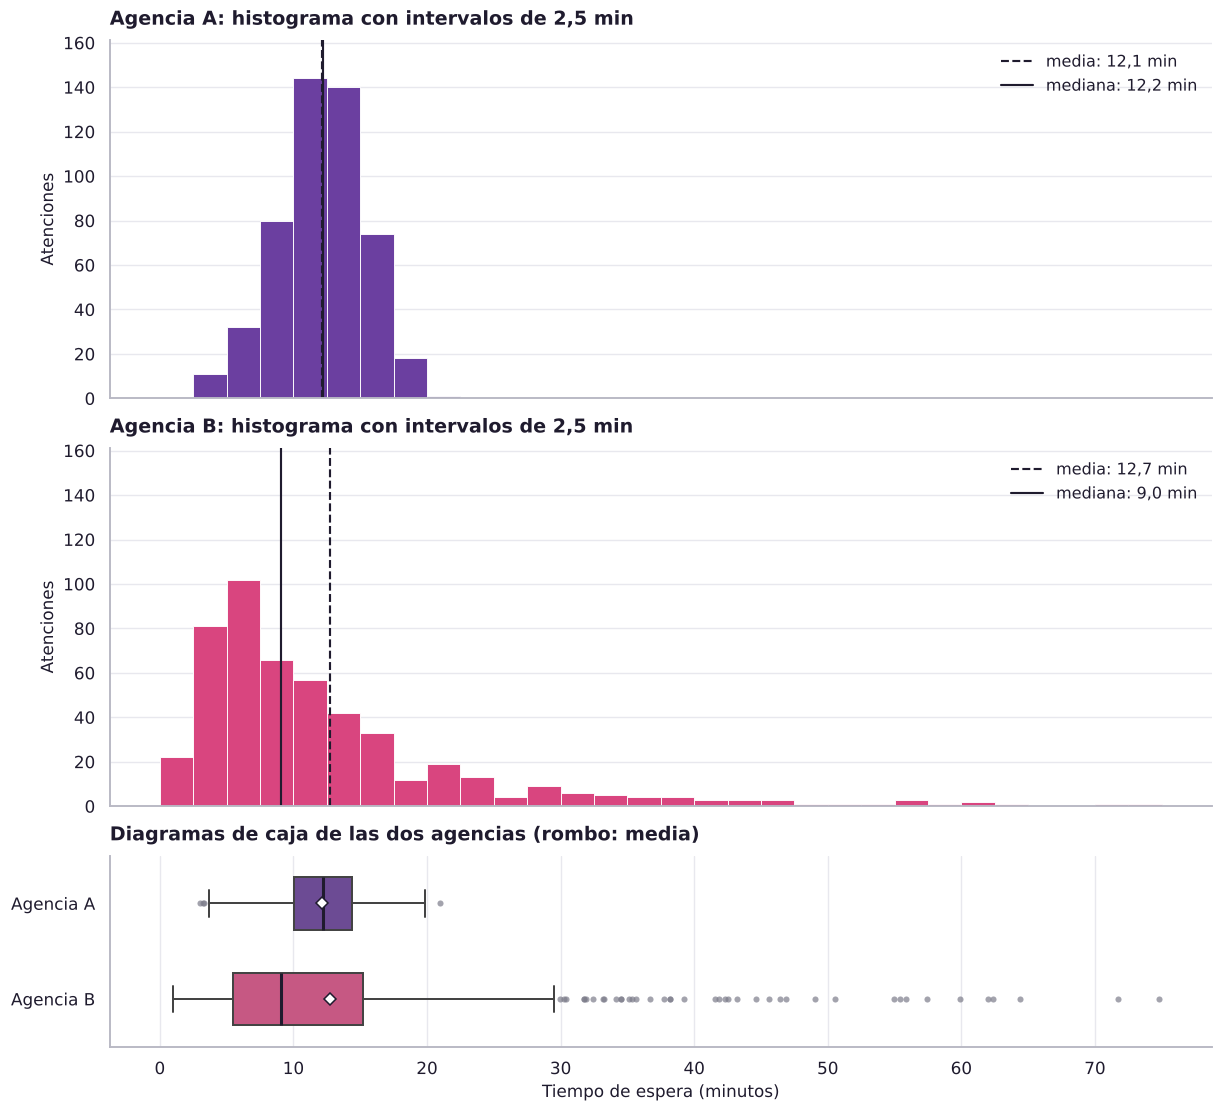

In [15]:
ancho = 2.5
bordes = np.arange(0, np.ceil(servicio["espera_min"].max() / ancho) * ancho + ancho, ancho)
ymax_hist = max(np.histogram(x, bins=bordes)[0].max() for x in esperas.values()) * 1.12

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True, layout="constrained",
                         gridspec_kw={"height_ratios": [3, 3, 1.6]})

for ax, agencia in zip(axes[:2], AGENCIAS):
    x = esperas[agencia]
    sns.histplot(x=x, bins=bordes, color=COL_AGENCIA[agencia], edgecolor="white", linewidth=0.6, alpha=1, ax=ax)
    ax.axvline(x.mean(), color=INK, ls="--", lw=1.4, label=f"media: {n_es(x.mean(), 1)} min")
    ax.axvline(x.median(), color=INK, ls="-", lw=1.4, label=f"mediana: {n_es(x.median(), 1)} min")
    ax.set_ylim(0, ymax_hist)
    ax.set_ylabel("Atenciones")
    ax.set_title(f"{agencia}: histograma con intervalos de {n_es(ancho, 1)} min")
    ax.legend(loc="upper right")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

ax = axes[2]
sns.boxplot(data=servicio, x="espera_min", y="agencia", hue="agencia", order=AGENCIAS, hue_order=AGENCIAS,
            palette=COL_AGENCIA, orient="h", width=0.55, whis=1.5, showmeans=True, legend=False,
            meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor=INK, markersize=6),
            medianprops=dict(color=INK, lw=2), flierprops=dict(marker="o", markersize=4, markerfacecolor=GRAY, markeredgecolor="none", alpha=0.7),
            linewidth=1.3, ax=ax)
ax.set_ylabel("")
ax.set_title("Diagramas de caja de las dos agencias (rombo: media)")
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.set_xlabel("Tiempo de espera (minutos)")
plt.show()

**Histograma.** En la Agencia A los tiempos forman una campana estrecha y casi simétrica: media y mediana coinciden (12,1 y 12,2) y la mitad central de las atenciones queda entre 10,1 y 14,4 minutos; la espera máxima es 21,0. En la B el máximo de la distribución se da entre 5 y 7,5 minutos y hay una cola larga hacia la derecha que llega a 74,8; la media (12,7) se desplaza hacia esa cola, lejos de la mediana (9,0), y el 8,0 % de las atenciones supera los 30 minutos, algo que no ocurre en A. El histograma muestra la concentración, la asimetría y la presencia de valores extremos, y con ello responde a la pregunta inicial: en A, la mayor parte de los tiempos está cerca del promedio; en B, no.

**Boxplot.** La caja va del primer al tercer cuartil (10,1 a 14,4 minutos en A; 5,5 a 15,2 en B), de modo que contiene la mitad central de los datos; la línea interior es la mediana y el rombo marca la media. Los bigotes llegan hasta el dato más alejado que no supere 1,5 veces el rango intercuartílico desde la caja, la convención de Tukey que usan por defecto matplotlib y seaborn; otras convenciones usan percentiles fijos o el mínimo y el máximo, por lo que conviene declarar cuál se aplica. Los puntos más allá de los bigotes son observaciones inusuales según esa regla, no errores: en B hay 41 (poco más del 8 % de las atenciones) y en A hay 4, todos a pocos minutos de los bigotes. En B corresponden a esperas reales de hasta 74,8 minutos, que son quizá las que más pesan en la experiencia del cliente; eliminarlas por reflejo ocultaría la característica distintiva de esa agencia. Antes de descartar un valor extremo hay que averiguar su origen.

**Qué ofrece cada uno.** El boxplot condensa un grupo en cinco números más sus extremos y por eso permite comparar medianas, dispersión y colas de varios grupos en poco espacio; en este caso deja ver de inmediato que la caja de B es más ancha y que su bigote superior llega mucho más lejos. Lo que no muestra es la forma: dos grupos con cajas idénticas podrían tener distribuciones muy diferentes, por ejemplo una con un solo pico y otra con dos. El histograma conserva esa forma y el conteo por tramo, pero con muchos grupos obliga a apilar paneles. Como regla práctica, conviene el histograma para entender un grupo o comparar dos, y el boxplot para comparar muchos; con pocas observaciones, mostrar los puntos individuales es más honesto que cualquier resumen.

**Anchura de los intervalos.** La apariencia de un histograma depende del ancho de sus intervalos. La siguiente figura dibuja las esperas de la Agencia B con tres anchos distintos.

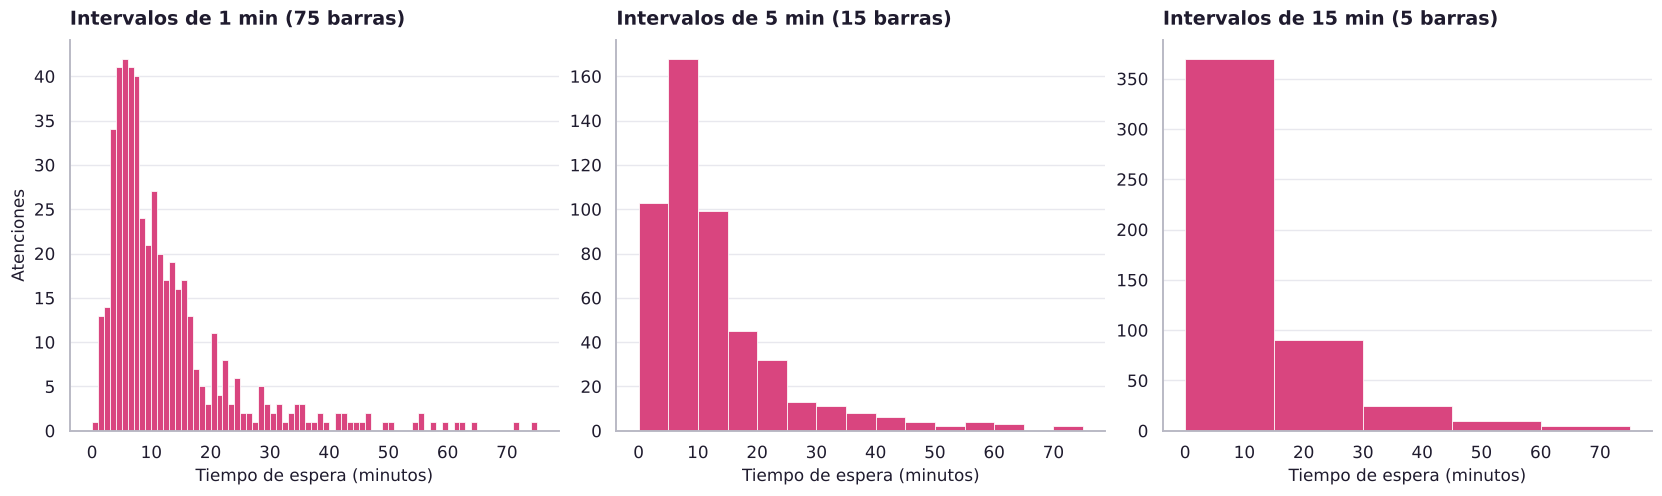

In [16]:
x = esperas["Agencia B"]
anchos = [1, 5, 15]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), sharex=True, layout="constrained")
for ax, w in zip(axes, anchos):
    b = np.arange(0, np.ceil(x.max() / w) * w + w, w)
    sns.histplot(x=x, bins=b, color=PINK, edgecolor="white", linewidth=0.5, alpha=1, ax=ax)
    ax.set_title(f"Intervalos de {w} min ({len(b) - 1} barras)")
    ax.set_xlabel("Tiempo de espera (minutos)")
    ax.set_ylabel("Atenciones" if ax is axes[0] else "")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
plt.show()

Con intervalos de 1 minuto (75 barras) cada barra contiene pocas atenciones y la cola luce irregular, con picos y huecos que son sobre todo azar muestral. Con 5 minutos (15 barras) la forma es estable: un máximo entre 5 y 10 minutos y una cola que decae gradualmente. Con 15 minutos (5 barras) el primer intervalo concentra el 74 % de las atenciones y se pierde la diferencia entre el tramo de 5 a 10 minutos y el de 10 a 15. Ninguna anchura es correcta en abstracto: depende de la cantidad de datos y de la resolución que importa para decidir (si el umbral de servicio fuera 15 minutos, un intervalo que termine justo en 15 sería útil). Conviene probar dos o tres anchos y, al comparar grupos, usar los mismos intervalos en todos, como se hizo en la figura anterior.

## 4. Relación: cómo varían dos variables juntas

**Pregunta:** ¿cómo cambia la satisfacción cuando aumenta el tiempo de espera?

En un gráfico de dispersión cada punto es una observación —aquí, una atención—, con su posición horizontal dada por una variable y la vertical por la otra. No se resume nada: se ve la tendencia, la dispersión alrededor de ella y los casos aislados. Los dos paneles siguientes muestran una asociación aproximadamente lineal (400 atenciones elegidas al azar de `servicio`) y otra con curvatura (104 semanas de `campanas`). En ambos se añaden dos resúmenes como ayuda de lectura: una recta de ajuste y el promedio de la variable vertical en ocho tramos de la horizontal.

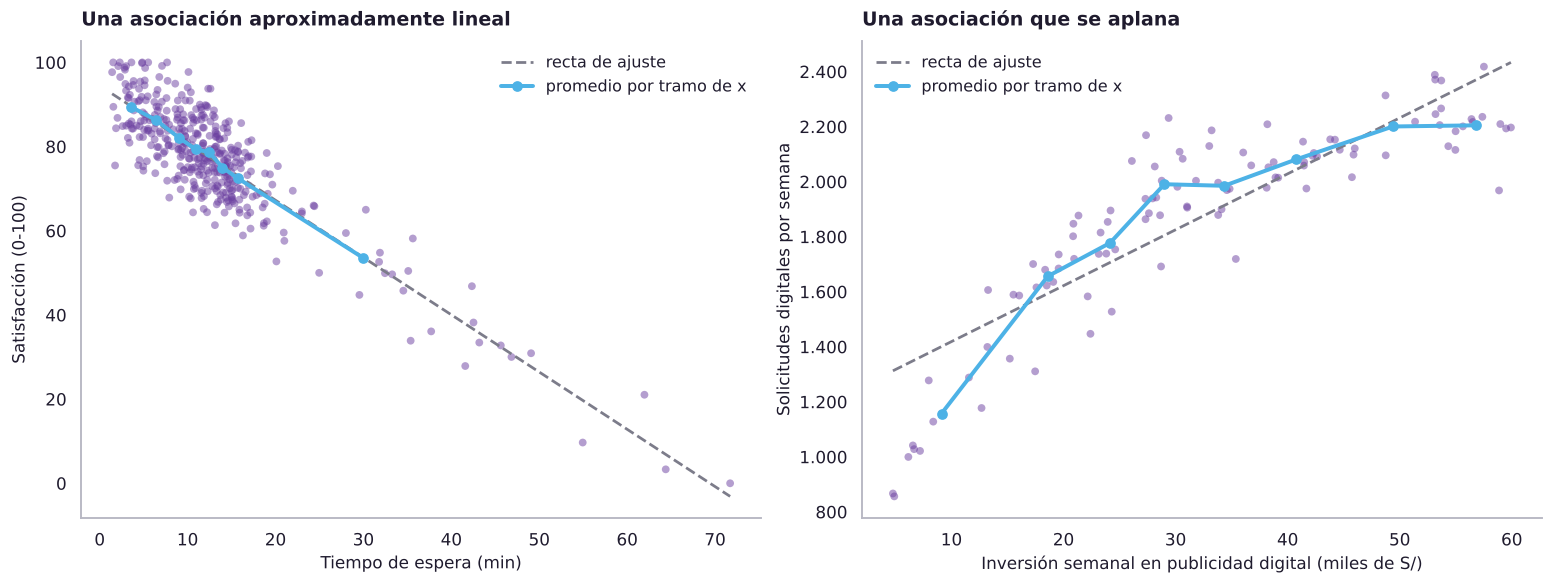

Correlación de Pearson: espera-satisfacción r = -0,87 | inversión-solicitudes r = 0,86
Inversión menos de 20 mil S/: 1.357 solicitudes por semana en promedio (23 semanas)
Inversión de 20 a 40 mil S/: 1.926 solicitudes por semana en promedio (47 semanas)
Inversión de 40 a 60 mil S/: 2.175 solicitudes por semana en promedio (34 semanas)


In [17]:
def promedios_por_tramo(x, y, tramos=8):
    cortes = pd.qcut(x, tramos)
    g = pd.DataFrame({"x": x, "y": y}).groupby(cortes, observed=True).mean()
    return g["x"], g["y"]


muestra = servicio.sample(400, random_state=SEED)
panel_a = (muestra["espera_min"], muestra["satisfaccion"])
panel_b = (campanas["inversion_miles"], campanas["solicitudes_digitales"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), layout="constrained")
for ax, (x, y), titulo, xl, yl in [
    (axes[0], panel_a, "Una asociación aproximadamente lineal", "Tiempo de espera (min)", "Satisfacción (0-100)"),
    (axes[1], panel_b, "Una asociación que se aplana", "Inversión semanal en publicidad digital (miles de S/)", "Solicitudes digitales por semana"),
]:
    ax.scatter(x, y, s=26, color=PURPLE, alpha=0.5, edgecolor="none")
    pend, ord_ = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 50)
    ax.plot(xs, ord_ + pend * xs, color=GRAY, ls="--", lw=1.8, label="recta de ajuste")
    tx, ty = promedios_por_tramo(x, y)
    ax.plot(tx, ty, color=SKY, lw=2.6, marker="o", ms=6, label="promedio por tramo de x")
    ax.set_title(titulo)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.legend(loc="best")
axes[1].yaxis.set_major_formatter(fmt_n)
plt.show()

r_lineal = np.corrcoef(*panel_a)[0, 1]
r_curva = np.corrcoef(*panel_b)[0, 1]
print(f"Correlación de Pearson: espera-satisfacción r = {n_es(r_lineal, 2)} | inversión-solicitudes r = {n_es(r_curva, 2)}")

tramos_inv = pd.cut(campanas["inversion_miles"], [0, 20, 40, 60], labels=["menos de 20", "de 20 a 40", "de 40 a 60"])
prom_tramos = campanas.groupby(tramos_inv, observed=True)["solicitudes_digitales"].agg(["mean", "size"])
for nombre, fila in prom_tramos.iterrows():
    print(f"Inversión {nombre} mil S/: {n_es(fila['mean'])} solicitudes por semana en promedio ({int(fila['size'])} semanas)")

**Panel izquierdo.** La dirección es decreciente, la forma es aproximadamente lineal —los promedios por tramo siguen la recta— y la dispersión es moderada: a igual espera, la satisfacción abarca un rango de unos 30 puntos. Las esperas largas son escasas y coinciden con satisfacción baja. Algunos puntos se apilan en 100 porque la escala no admite valores mayores. El coeficiente de correlación (r = −0,87) resume la parte lineal, pero no reemplaza la mirada: el mismo valor de r puede corresponder a formas muy distintas.

**Panel derecho.** Aquí r = 0,86, un valor alto, y sin embargo la relación no es lineal. Los promedios por tramo muestran rendimientos decrecientes: las semanas con menos de 20 mil soles de inversión promedian 1.357 solicitudes digitales, las de 20 a 40 mil promedian 1.926 y las de 40 a 60 mil, 2.175. Pasar del primer al segundo tramo suma 569 solicitudes y del segundo al tercero solo 249, aunque los tramos tienen el mismo ancho. La recta sobrestima en los extremos y subestima en el centro, y un r alto no garantiza que una recta sea una buena descripción. La curva es parte del diseño de la simulación: no constituye evidencia sobre el rendimiento real de ninguna inversión publicitaria.

**Por qué no unir los puntos.** Una línea entre puntos sugiere un orden —que el segundo sigue al primero y que entre ambos hay una transición—. En una dispersión de clientes o atenciones, el orden de las filas es arbitrario (el de alta en la base, por ejemplo), y una línea que las recorra produciría una maraña sin significado. Las líneas se justifican cuando existe un orden con sentido, como el tiempo; la recta de ajuste y los promedios por tramo usados arriba son resúmenes de la nube, no conexiones entre observaciones.

**Pregunta:** ¿los clientes que realizan más transacciones mueven montos mayores?

El conjunto `clientes` reúne 3.000 clientes de tres segmentos. El panel izquierdo los muestra a todos juntos; el derecho, el mismo conjunto con color y forma de marcador por segmento, y con una recta de ajuste dentro de cada uno.

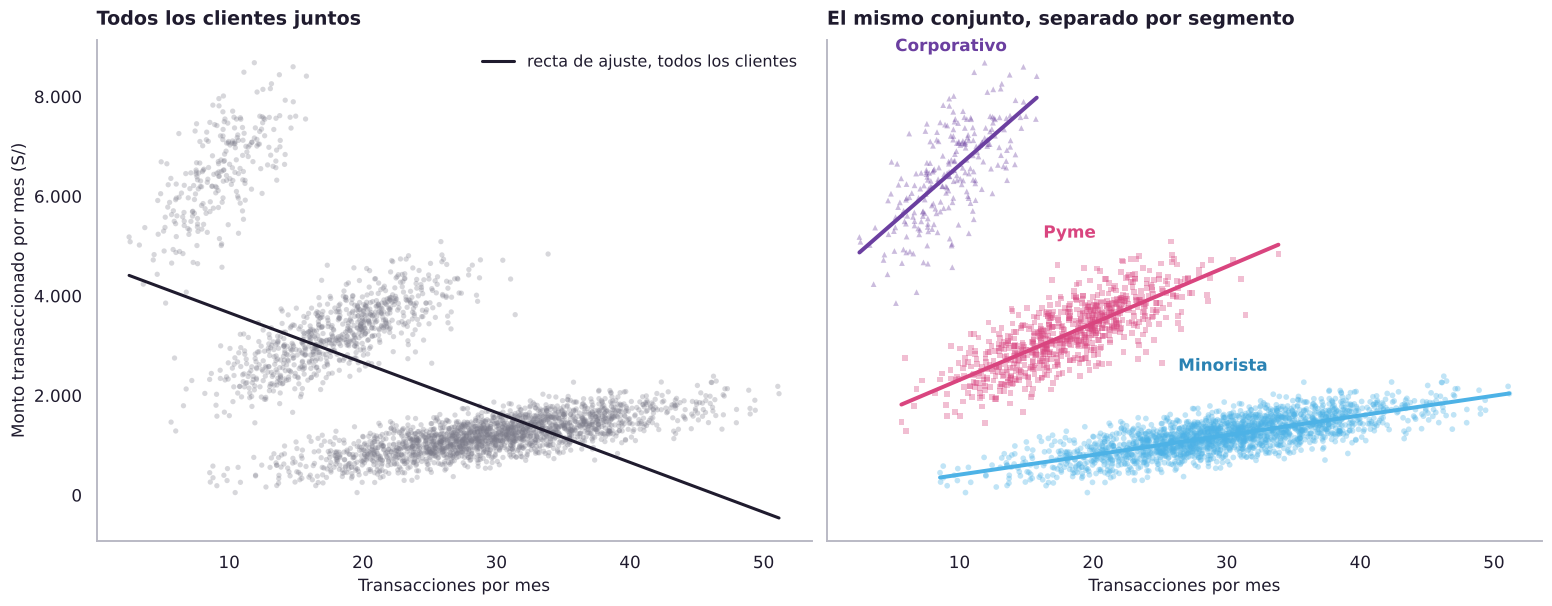

Todos los clientes: r = -0,56, pendiente = -100 S/ por transacción adicional
  Corporativo: r = 0,68, pendiente = 234 S/ por transacción adicional
  Minorista: r = 0,75, pendiente = 40 S/ por transacción adicional
  Pyme: r = 0,77, pendiente = 114 S/ por transacción adicional


In [18]:
r_global = np.corrcoef(clientes["transacciones_mes"], clientes["monto_mes"])[0, 1]
r_seg = {s: np.corrcoef(d["transacciones_mes"], d["monto_mes"])[0, 1] for s, d in clientes.groupby("segmento")}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4), sharex=True, sharey=True, layout="constrained")

ax = axes[0]
ax.scatter(clientes["transacciones_mes"], clientes["monto_mes"], s=12, color=GRAY, alpha=0.3, edgecolor="none")
pend, ord_ = np.polyfit(clientes["transacciones_mes"], clientes["monto_mes"], 1)
xs = np.linspace(clientes["transacciones_mes"].min(), clientes["transacciones_mes"].max(), 50)
ax.plot(xs, ord_ + pend * xs, color=INK, lw=2, label="recta de ajuste, todos los clientes")
ax.set_title("Todos los clientes juntos")
ax.legend(loc="upper right")

ax = axes[1]
for seg in SEGMENTOS:
    d = clientes[clientes["segmento"] == seg]
    ax.scatter(d["transacciones_mes"], d["monto_mes"], s=14, color=COL_SEG[seg], marker=MARK_SEG[seg], alpha=0.35, edgecolor="none")
    p, o = np.polyfit(d["transacciones_mes"], d["monto_mes"], 1)
    xs = np.linspace(d["transacciones_mes"].min(), d["transacciones_mes"].max(), 50)
    ax.plot(xs, o + p * xs, color=COL_SEG[seg], lw=2.6)
    ax.text(d["transacciones_mes"].median(), d["monto_mes"].quantile(0.99) + 450, seg,
            color=COL_SEG[seg] if seg != "Minorista" else "#2A82B3", fontweight="bold", ha="center", fontsize=11)
ax.set_title("El mismo conjunto, separado por segmento")

for ax in axes:
    ax.set_xlabel("Transacciones por mes")
    ax.yaxis.set_major_formatter(fmt_n)
axes[0].set_ylabel("Monto transaccionado por mes (S/)")
plt.show()

pend_global = np.polyfit(clientes["transacciones_mes"], clientes["monto_mes"], 1)[0]
print(f"Todos los clientes: r = {n_es(r_global, 2)}, pendiente = {n_es(pend_global)} S/ por transacción adicional")
for seg_, d_ in clientes.groupby("segmento"):
    pend_seg = np.polyfit(d_["transacciones_mes"], d_["monto_mes"], 1)[0]
    print(f"  {seg_}: r = {n_es(r_seg[seg_], 2)}, pendiente = {n_es(pend_seg)} S/ por transacción adicional")

En la vista general, la recta desciende (aproximadamente −100 soles por transacción adicional) y la lectura natural sería que más transacciones acompañan montos menores. Al separar por segmento aparece lo contrario: dentro de cada uno la asociación es creciente (r de 0,75 en Minorista, 0,77 en Pyme y 0,68 en Corporativo; pendientes de unos 40, 114 y 234 soles por transacción adicional). Lo que ocurre es que los segmentos con menos transacciones tienen montos mucho mayores, de modo que mezclarlos invierte el signo de la asociación. El color revela una estructura que la vista general oculta.

El color funciona aquí porque son tres grupos; con más de cinco o seis categorías se empasta, y entonces conviene un panel por grupo. Por eso las categorías también se distinguen por la forma del marcador y por etiquetas directas, y no solo por el color. Todo lo anterior describe cómo se mueven juntas dos variables en estos datos; una asociación visual no establece que una variable cause la otra ni que la relación se mantenga si se interviene sobre una de ellas. En datos reales, por ejemplo, la espera y la satisfacción también dependerían del tipo de trámite o de su resultado, y la dispersión no separa esos factores.

**Solapamiento.** Con 3.000 puntos, muchos coinciden en la misma zona. La figura siguiente dibuja los mismos clientes de tres maneras.

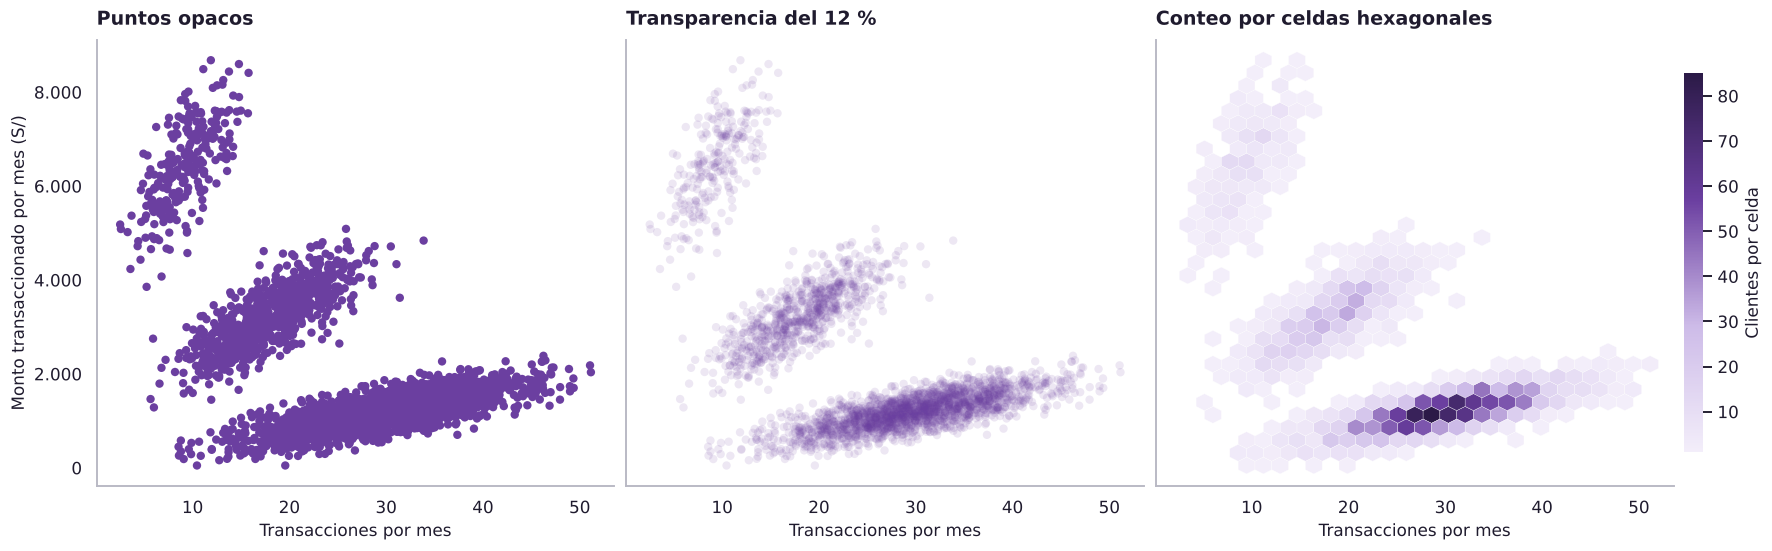

In [19]:
cmap_morado = LinearSegmentedColormap.from_list("morado", ["#F3EEFA", PURPLE_L, PURPLE, "#2B1A47"])
x, y = clientes["transacciones_mes"], clientes["monto_mes"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.9), sharex=True, sharey=True, layout="constrained")

axes[0].scatter(x, y, s=30, color=PURPLE, alpha=1, edgecolor="none")
axes[0].set_title("Puntos opacos")

axes[1].scatter(x, y, s=30, color=PURPLE, alpha=0.12, edgecolor="none")
axes[1].set_title("Transparencia del 12 %")

hb = axes[2].hexbin(x, y, gridsize=28, cmap=cmap_morado, mincnt=1, linewidths=0.2, edgecolors="white")
axes[2].set_title("Conteo por celdas hexagonales")
cb = fig.colorbar(hb, ax=axes[2], shrink=0.85, pad=0.02)
cb.set_label("Clientes por celda")
cb.outline.set_visible(False)

for ax in axes:
    ax.set_xlabel("Transacciones por mes")
    ax.yaxis.set_major_formatter(fmt_n)
axes[0].set_ylabel("Monto transaccionado por mes (S/)")
plt.show()

Con puntos opacos, el núcleo del segmento Minorista es una mancha uniforme: no se distingue una zona con 100 clientes de otra con 1.000. La transparencia deja que la densidad se traduzca en intensidad de color, a costa de que la escala sea difícil de leer en términos cuantitativos. Los hexágonos cuentan clientes por celda y permiten leer cuántos hay en cada zona, pero pierden los puntos individuales y dependen del tamaño de celda, igual que un histograma depende del ancho de sus intervalos. Reducir el tamaño de los puntos o dibujar una muestra aleatoria (declarada como tal) son otras opciones, y para variables discretas suele ayudar un pequeño desplazamiento aleatorio (*jitter*).

## 5. Composición: cómo se divide un total

**Pregunta:** ¿cómo se reparte el total de conversiones entre productos?

La variable es la participación de cada producto en las conversiones de 2023 y 2024 (113.057 conversiones en total). Los dos paneles siguientes representan exactamente las mismas cuatro participaciones: Cuenta de ahorros 43,1 %, Crédito de consumo 27,8 %, Tarjeta de crédito 20,7 % y Seguros 8,3 %.

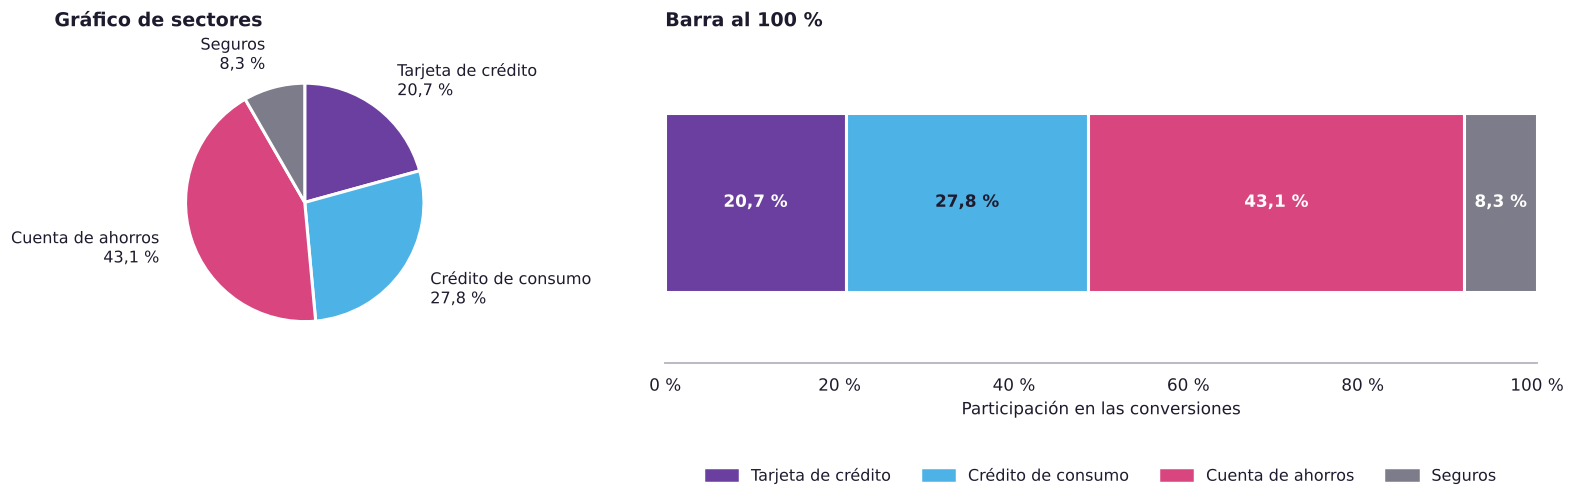

In [20]:
prod_tot = ops.groupby("producto")["conversiones"].sum().reindex(PRODUCTOS)
part = prod_tot / prod_tot.sum()

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.4), gridspec_kw={"width_ratios": [1, 1.35]}, layout="constrained")

ax = axes[0]
cuñas, _ = ax.pie(part.values, colors=[COL_PROD[p] for p in PRODUCTOS], startangle=90, counterclock=False,
                  wedgeprops=dict(edgecolor="white", linewidth=2))
for w, p, s in zip(cuñas, PRODUCTOS, part.values):
    ang = np.deg2rad((w.theta1 + w.theta2) / 2)
    cx, cy = np.cos(ang), np.sin(ang)
    ax.annotate(f"{p}\n{pct_es(s)}", xy=(cx, cy), xytext=(1.28 * cx, 1.28 * cy),
                ha="left" if cx >= 0 else "right", va="center", fontsize=10.5)
ax.set_xlim(-2.1, 2.1)
ax.set_ylim(-1.35, 1.35)
ax.set_title("Gráfico de sectores")

ax = axes[1]
inicio = 0
for p, s in zip(PRODUCTOS, part.values):
    ax.barh([0], [s * 100], left=inicio, color=COL_PROD[p], edgecolor="white", linewidth=2, height=0.5)
    ax.text(inicio + s * 50, 0, pct_es(s), ha="center", va="center", color=TXT_PROD[p], fontsize=11, fontweight="bold")
    inicio += s * 100
ax.set_xlim(0, 100)
ax.set_ylim(-0.45, 0.45)
ax.set_yticks([])
ax.xaxis.set_major_formatter(fmt_pct100)
ax.set_xlabel("Participación en las conversiones")
ax.spines["left"].set_visible(False)
ax.set_title("Barra al 100 %")
ax.legend(handles=[Patch(color=COL_PROD[p], label=p) for p in PRODUCTOS], loc="upper center",
          bbox_to_anchor=(0.5, -0.28), ncol=4)
plt.show()

Con cuatro categorías y una parte dominante, el gráfico de sectores es legible: se ve que Cuenta de ahorros ocupa algo más del 40 % y que Seguros es la parte menor, y para eso no hace falta estimar ángulos con precisión. Su fortaleza es transmitir la idea de un todo dividido en pocas partes. La barra al 100 % pone todos los segmentos en una misma dirección, lo que facilita compararlos (la diferencia de 7,1 puntos entre Crédito de consumo y Tarjeta de crédito se estima con longitudes y no con ángulos y áreas) y su eje permite leer acumulados: los dos productos de crédito suman 48,5 %, casi la mitad. Los experimentos de Cleveland y McGill [1] indican que estimar ángulos y áreas es menos preciso que estimar posiciones y longitudes, de modo que, si el mensaje exige comparar partes, la barra es la opción más segura.

El sector pierde utilidad con más categorías o con participaciones parecidas. La siguiente figura reparte las conversiones entre los ocho canales: los tres primeros concentran 31,9 %, 23,4 % y 21,9 %, y los cinco restantes 7,0 %, 5,6 %, 4,9 %, 4,3 % y 0,9 %.

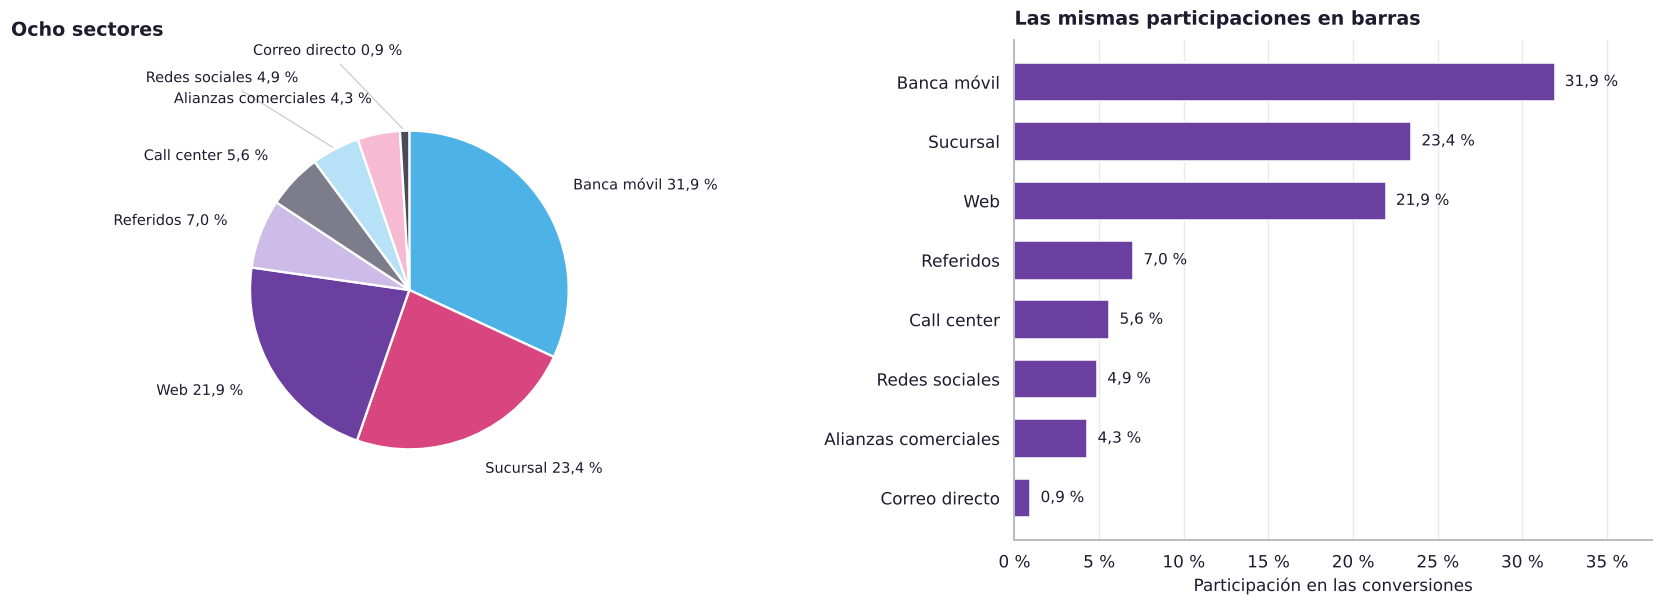

In [21]:
part_canal = (conv / conv.sum()).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.4), gridspec_kw={"width_ratios": [1.25, 1]}, layout="constrained")

ax = axes[0]
cuñas, _ = ax.pie(part_canal.values, colors=[COL_CANAL[c] for c in part_canal.index], startangle=90,
                  counterclock=False, wedgeprops=dict(edgecolor="white", linewidth=1.5))
for i, (w, c, s) in enumerate(zip(cuñas, part_canal.index, part_canal.values)):
    ang = np.deg2rad((w.theta1 + w.theta2) / 2)
    cx, cy = np.cos(ang), np.sin(ang)
    radio = 1.22 if s > 0.06 or i % 2 == 0 else 1.5      # escalona las etiquetas de sectores pequeños
    ax.annotate(f"{c} {pct_es(s)}", xy=(cx, cy), xytext=(radio * cx, radio * cy),
                ha="left" if cx >= 0 else "right", va="center", fontsize=9.5,
                arrowprops=dict(arrowstyle="-", color=GRAY_L, lw=0.8) if radio > 1.3 else None)
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title("Ocho sectores")

ax = axes[1]
orden = part_canal.sort_values()
ax.barh(orden.index, orden.values, color=PURPLE, height=0.65)
for y, v in enumerate(orden.values):
    ax.text(v + 0.006, y, pct_es(v), va="center", fontsize=10)
ax.set_xlim(0, orden.max() * 1.18)
ax.xaxis.set_major_formatter(fmt_pct)
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.set_xlabel("Participación en las conversiones")
ax.set_title("Las mismas participaciones en barras")
plt.show()

En el gráfico de sectores, ocho colores obligan a leer etiquetas para saber qué es cada porción, y las diferencias pequeñas son casi invisibles: 4,9 % (Redes sociales) frente a 4,3 % (Alianzas comerciales) se aprecia apenas en los sectores y de inmediato en las barras, que además están ordenadas. Cuando la pregunta es cuál categoría es mayor, o cómo se ordenan, el problema es de comparación entre categorías (sección 1) y no de composición, y las barras simples son la elección natural. El sector queda reservado para mensajes del tipo «una parte domina» o «alrededor de un cuarto del total», con pocas partes y etiquetas visibles.

**Pregunta:** ¿cómo se compone el volumen de conversiones de cada canal?

Para comparar la composición de varios grupos se pueden usar barras apiladas, que conservan el volumen, o barras al 100 %, que lo normalizan. La figura usa los mismos cinco canales y los mismos productos en ambos paneles, ordenados de mayor a menor volumen.

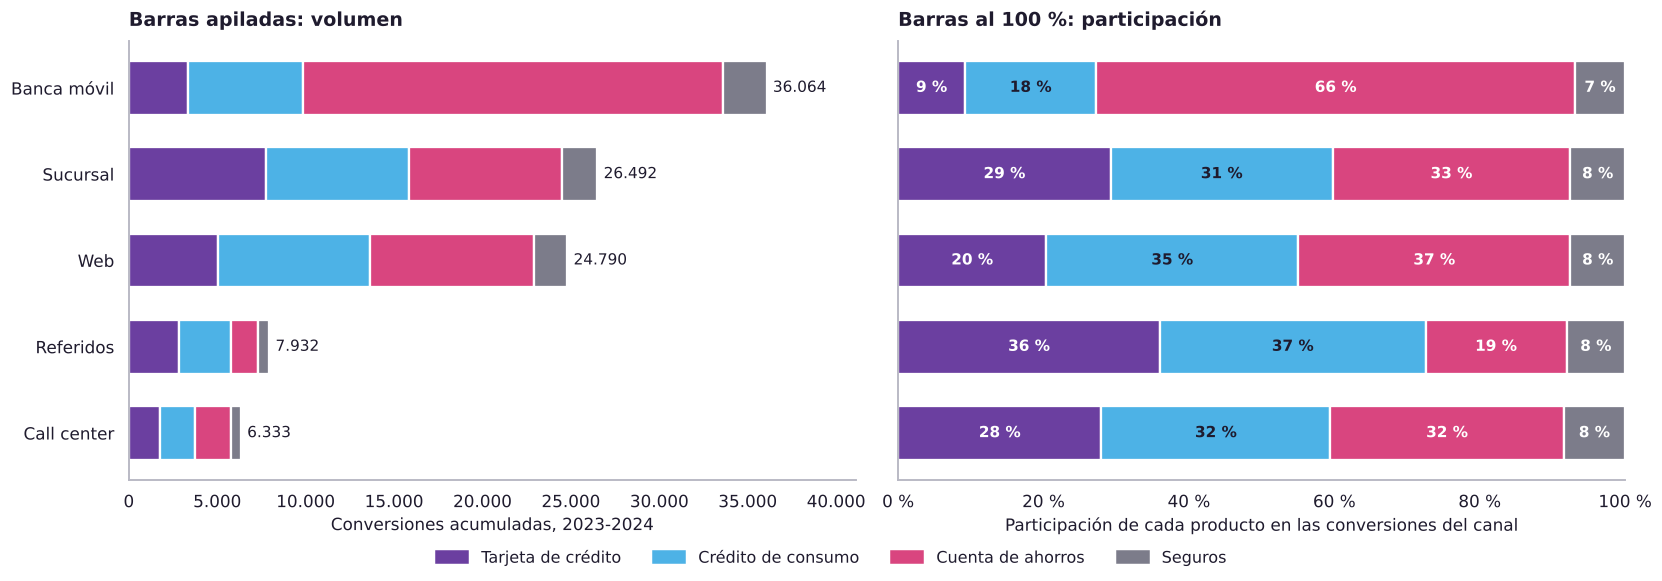

Conversiones de Cuenta de ahorros por canal: {'Banca móvil': '23.747', 'Sucursal': '8.655', 'Web': '9.280', 'Referidos': '1.538', 'Call center': '2.032'}


,Conversiones,Tarjeta de crédito,Crédito de consumo,Cuenta de ahorros,Seguros
canal,,,,,
Banca móvil,36.064,"9,2 %","18,1 %","65,8 %","6,9 %"
Sucursal,26.492,"29,3 %","30,5 %","32,7 %","7,5 %"
Web,24.790,"20,4 %","34,7 %","37,4 %","7,5 %"
Referidos,7.932,"36,0 %","36,5 %","19,4 %","8,1 %"
Call center,6.333,"28,0 %","31,5 %","32,1 %","8,4 %"


In [22]:
canales_comp = ["Banca móvil", "Sucursal", "Web", "Call center", "Referidos"]
comp = (ops.pivot_table(index="canal", columns="producto", values="conversiones", aggfunc="sum")[PRODUCTOS]
        .loc[canales_comp])
comp = comp.loc[comp.sum(axis=1).sort_values(ascending=False).index]          # de mayor a menor volumen
comp_pct = comp.div(comp.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2), sharey=True, layout="constrained")
filas_y = np.arange(len(comp))[::-1]

ax = axes[0]
izq = np.zeros(len(comp))
for p in PRODUCTOS:
    ax.barh(filas_y, comp[p].values, left=izq, color=COL_PROD[p], edgecolor="white", linewidth=1.5, height=0.62)
    izq += comp[p].values
for y, total in zip(filas_y, comp.sum(axis=1)):
    ax.text(total + comp.sum(axis=1).max() * 0.01, y, n_es(total), va="center", fontsize=10)
ax.set_xlim(0, comp.sum(axis=1).max() * 1.14)
ax.xaxis.set_major_formatter(fmt_n)
ax.set_xlabel("Conversiones acumuladas, 2023-2024")
ax.set_title("Barras apiladas: volumen")

ax = axes[1]
izq = np.zeros(len(comp))
for p in PRODUCTOS:
    ax.barh(filas_y, comp_pct[p].values * 100, left=izq, color=COL_PROD[p], edgecolor="white", linewidth=1.5, height=0.62)
    for y, s, i0 in zip(filas_y, comp_pct[p].values, izq):
        if s > 0.06:
            ax.text(i0 + s * 50, y, f"{n_es(s * 100)} %", ha="center", va="center", color=TXT_PROD[p], fontsize=10, fontweight="bold")
    izq += comp_pct[p].values * 100
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(fmt_pct100)
ax.set_xlabel("Participación de cada producto en las conversiones del canal")
ax.set_title("Barras al 100 %: participación")

axes[0].set_yticks(filas_y)
axes[0].set_yticklabels(comp.index)
fig.legend(handles=[Patch(color=COL_PROD[p], label=p) for p in PRODUCTOS], loc="outside lower center", ncol=4)
plt.show()

print("Conversiones de Cuenta de ahorros por canal:",
      {c: n_es(comp.loc[c, "Cuenta de ahorros"]) for c in comp.index})
tabla_comp = pd.DataFrame({
    "Conversiones": comp.sum(axis=1).map(n_es),
    **{p: comp_pct[p].map(pct_es) for p in PRODUCTOS},
})
tabla_comp

**Volumen frente a participación.** Las barras apiladas responden a «¿cuánto aporta cada canal y de qué productos?»; las barras al 100 % responden a «¿cómo se reparte cada canal?». En la normalizada todas las barras miden lo mismo, de modo que ya no informan del tamaño: Banca móvil (36.064 conversiones) y Call center (6.333) ocupan el mismo ancho. Normalizar es adecuado para comparar mezclas y engañoso si el lector olvida que cada barra pesa distinto; por eso conviene mostrar el volumen cerca, como en el panel izquierdo, o anotarlo.

**La línea de base.** En ambas versiones solo el primer segmento (Tarjeta de crédito) parte de la misma línea de base; los demás empiezan donde termina el anterior. Comparar entre canales el aporte de Cuenta de ahorros exige restar posiciones. En el panel izquierdo, el segmento de Cuenta de ahorros de Web (9.280 conversiones) es apenas 7 % mayor que el de Sucursal (8.655), y la diferencia es muy difícil de juzgar a ojo porque los segmentos están desplazados. Si la pregunta se centra en un producto, es preferible dibujar solo ese producto —volumen o participación por canal— en barras simples con base común, o usar un panel por producto. Ordenar los canales por el primer segmento, como se hizo en la sección 6, ayuda a leer al menos esa parte.

**Un caso: composiciones parecidas, volúmenes muy distintos.** Sucursal y Call center, dos de los canales de la figura, tienen una composición casi idéntica y un volumen muy diferente. La tabla impresa bajo la figura lo cuantifica. Sucursal acumula 26.492 conversiones y Call center 6.333, es decir, 4,2 veces menos, pero sus participaciones son casi iguales: 29,3 %, 30,5 %, 32,7 % y 7,5 % en Sucursal frente a 28,0 %, 31,5 %, 32,1 % y 8,4 % en Call center (Tarjeta de crédito, Crédito de consumo, Cuenta de ahorros y Seguros, respectivamente). Las barras apiladas muestran que se trata de canales de tamaño muy distinto; las barras al 100 % muestran que, en mezcla de productos, apenas se diferencian. Ninguna de las dos vistas es la verdadera: responden a preguntas distintas, y presentar solo una produciría una conclusión incompleta.

## 6. Un mismo conjunto de datos, varias preguntas

Un equipo comercial revisa el desempeño de sus canales. Con la misma tabla `ops` pueden plantearse preguntas muy distintas, y cada una obliga a decidir qué calcular antes de decidir cómo dibujarlo. La primera celda prepara dos vistas de la tabla: el año 2024 y una agrupación que separa Web del resto de canales.

In [23]:
ops24 = ops[ops["mes"].dt.year == 2024]
ops_web_resto = ops.assign(grupo=np.where(ops["canal"] == "Web", "Web", "Resto de canales"))

**Pregunta 1: ¿qué canales convirtieron mejor en 2024?**

La medida es la tasa de conversión del año, calculada por canal sobre sus propias solicitudes. Se usa la tasa y no el conteo porque la pregunta es qué tan bien convierte cada canal, con independencia de su tamaño. Cada barra lleva anotado su denominador: una tasa alta sobre pocas solicitudes (Referidos, 44,2 % sobre 9.420) no merece la misma confianza que una calculada sobre muchas (Banca móvil, 34,4 % sobre 61.972).

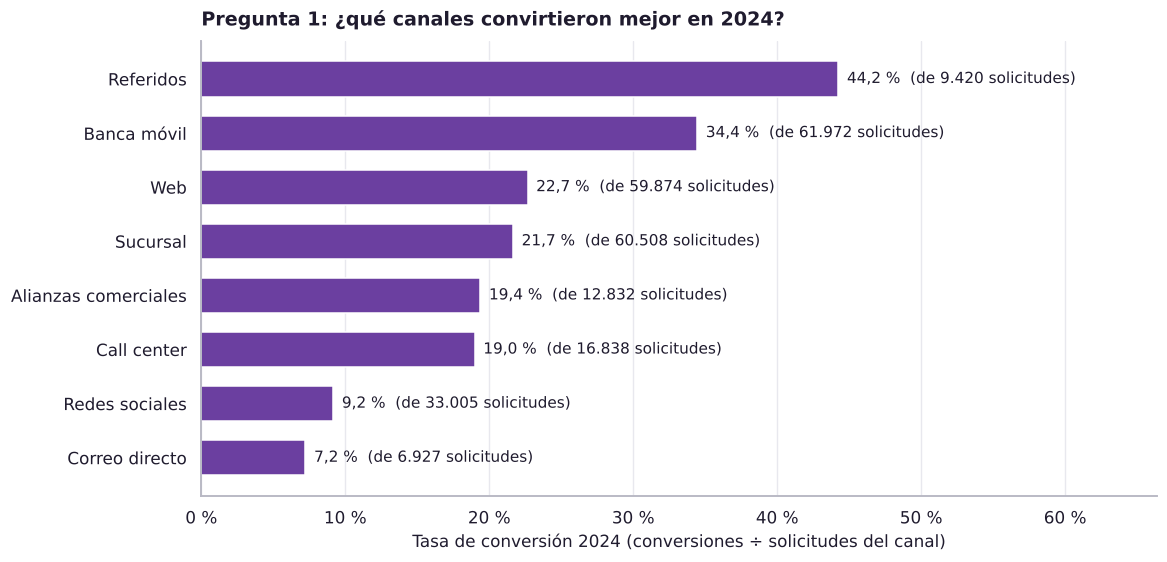

In [24]:
t24 = (ops24.groupby("canal")[["solicitudes", "conversiones"]].sum()
       .assign(tasa=lambda d: d["conversiones"] / d["solicitudes"])
       .sort_values("tasa"))

fig, ax = plt.subplots(figsize=(10.5, 5), layout="constrained")
ax.barh(t24.index, t24["tasa"], color=PURPLE, height=0.65)
for y, (tasa, sol) in enumerate(zip(t24["tasa"], t24["solicitudes"])):
    ax.text(tasa + 0.006, y, f"{pct_es(tasa)}  (de {n_es(sol)} solicitudes)", va="center", fontsize=10)
ax.set_xlim(0, t24["tasa"].max() * 1.5)
ax.xaxis.set_major_formatter(fmt_pct)
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.set_xlabel("Tasa de conversión 2024 (conversiones ÷ solicitudes del canal)")
ax.set_title("Pregunta 1: ¿qué canales convirtieron mejor en 2024?")
plt.show()

Web (22,7 %) y Sucursal (21,7 %) quedan a un punto porcentual con volúmenes casi iguales (59.874 y 60.508 solicitudes); este gráfico no permite distinguir esa diferencia de la variación habitual, así que no sostiene afirmar que uno sea mejor que el otro. Sí separa con claridad tres grupos: Referidos y Banca móvil por encima del 34 %, cuatro canales entre 19 % y 23 %, y Redes sociales y Correo directo por debajo de 10 %.

**Pregunta 2: ¿cómo evolucionó la tasa de conversión del canal Web frente al resto?**

Ahora cambian la pregunta (evolución, no comparación), la agregación (mes a mes, durante los 24 meses) y el grupo de comparación (Web frente al conjunto de los demás canales). La tasa de cada mes se calcula sumando conversiones y solicitudes dentro de cada grupo y dividiendo después, no promediando las tasas de los canales.

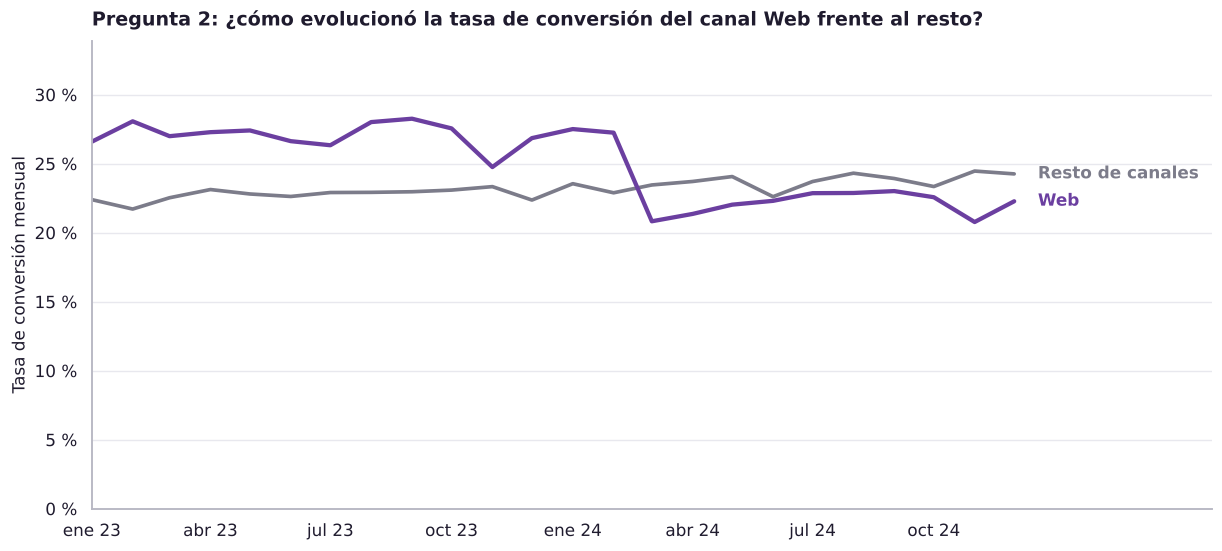

Resto de canales: tasa 22,8 % (ene 23 - feb 24) -> 23,8 % (mar 24 - dic 24)
Web: tasa 27,1 % (ene 23 - feb 24) -> 22,1 % (mar 24 - dic 24)
Web, solicitudes mensuales promedio: 3.423 -> 5.345
Web, conversiones mensuales promedio: 927 -> 1.181


In [25]:
m = ops_web_resto.groupby(["mes", "grupo"])[["solicitudes", "conversiones"]].sum()
tasa_m = (m["conversiones"] / m["solicitudes"]).unstack()

fig, ax = plt.subplots(figsize=(11, 4.9), layout="constrained")
for g, color, lw in [("Resto de canales", GRAY, 2.4), ("Web", PURPLE, 2.8)]:
    ax.plot(tasa_m.index, tasa_m[g], color=color, lw=lw)
    ax.text(tasa_m.index[-1] + pd.Timedelta(days=18), tasa_m[g].iloc[-1], g, color=color, va="center",
            fontsize=11, fontweight="bold")
ax.set_xlim(tasa_m.index[0], tasa_m.index[-1] + pd.Timedelta(days=150))
ax.set_ylim(0, tasa_m.to_numpy().max() * 1.2)
ejes_tiempo(ax, tasa_m.index)
ax.yaxis.set_major_formatter(fmt_pct)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.set_ylabel("Tasa de conversión mensual")
ax.set_title("Pregunta 2: ¿cómo evolucionó la tasa de conversión del canal Web frente al resto?")
plt.show()

corte_web = pd.Timestamp("2024-03-01")
for grupo_, d in ops_web_resto.groupby("grupo"):
    antes_, despues_ = d[d["mes"] < corte_web], d[d["mes"] >= corte_web]
    print(f"{grupo_}: tasa {pct_es(antes_['conversiones'].sum() / antes_['solicitudes'].sum())} (ene 23 - feb 24) "
          f"-> {pct_es(despues_['conversiones'].sum() / despues_['solicitudes'].sum())} (mar 24 - dic 24)")
web_m = ops_web_resto[ops_web_resto["grupo"] == "Web"].groupby("mes")[["solicitudes", "conversiones"]].sum()
for col in ["solicitudes", "conversiones"]:
    print(f"Web, {col} mensuales promedio: {n_es(web_m[web_m.index < corte_web][col].mean())} -> {n_es(web_m[web_m.index >= corte_web][col].mean())}")

La tasa de Web pasa de 27,1 % entre enero de 2023 y febrero de 2024 a 22,1 % entre marzo y diciembre de 2024, mientras que la del resto de canales se mantiene estable (22,8 % antes y 23,8 % después). La caída de Web comienza en marzo de 2024, el mismo mes en que empieza el nivel más alto de solicitudes: el promedio mensual de solicitudes del canal pasa de 3.423 en el periodo anterior a 5.345 en el posterior, y el de conversiones, de 927 a 1.181. Web convierte más solicitudes, pero una proporción menor de ellas: un gráfico de conversiones diría que el canal mejoró, y uno de tasas que se deterioró. Ambas lecturas son correctas y responden preguntas distintas. Los datos solo muestran que los dos cambios ocurren juntos; no indican por qué, y en un caso real habría que investigarlo (mezcla de visitantes, cambios en el proceso de solicitud, entre otras posibilidades).

**Pregunta 3: ¿qué productos sostienen las conversiones de cada canal en 2024?**

Cambian de nuevo la pregunta (composición), el denominador (las conversiones totales del canal, ya no sus solicitudes) y la variable mostrada (la participación de cada producto). Los canales se ordenan por la participación de Tarjeta de crédito, el único segmento que comparte línea de base.

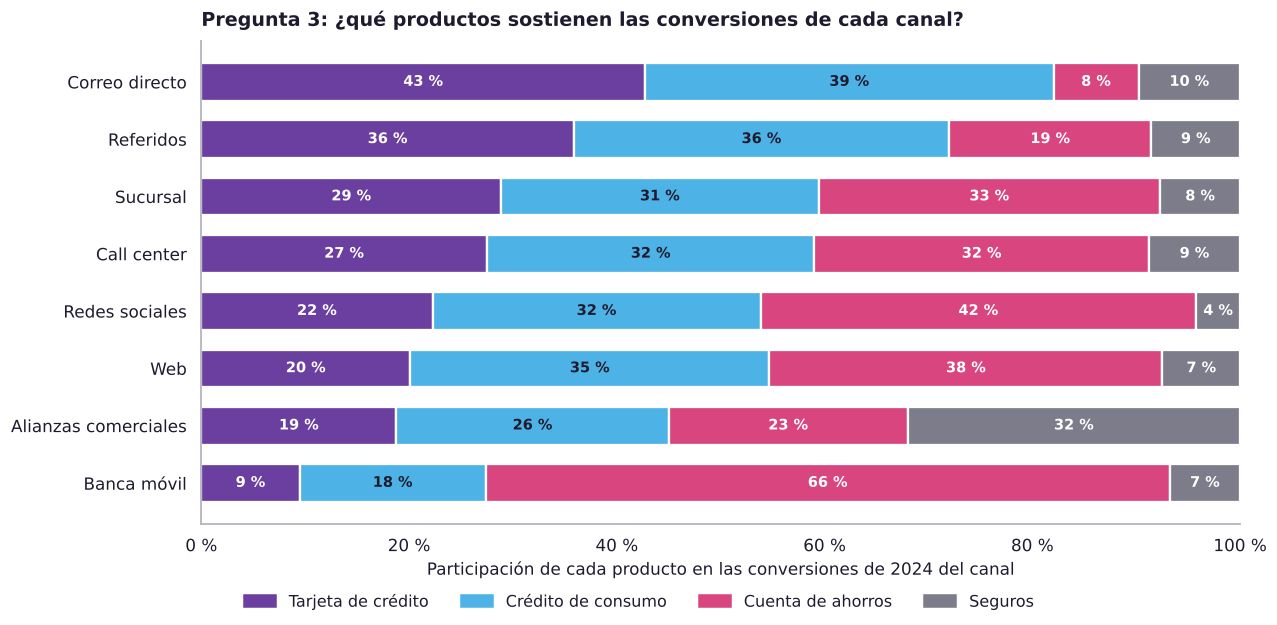

In [26]:
comp24 = ops24.pivot_table(index="canal", columns="producto", values="conversiones", aggfunc="sum")[PRODUCTOS]
share24 = comp24.div(comp24.sum(axis=1), axis=0).sort_values("Tarjeta de crédito")
ys = np.arange(len(share24))

fig, ax = plt.subplots(figsize=(11.5, 5.6), layout="constrained")
izq = np.zeros(len(share24))
for p in PRODUCTOS:
    vals = share24[p].values * 100
    ax.barh(ys, vals, left=izq, color=COL_PROD[p], edgecolor="white", linewidth=1.5, height=0.66)
    for y, s, i0 in zip(ys, share24[p].values, izq):
        if s > 0.04:
            ax.text(i0 + s * 50, y, f"{n_es(s * 100)} %", ha="center", va="center", color=TXT_PROD[p], fontsize=9.5, fontweight="bold")
    izq += vals
ax.set_yticks(ys)
ax.set_yticklabels(share24.index)
ax.set_xlim(0, 100)
ax.xaxis.set_major_formatter(fmt_pct100)
ax.set_xlabel("Participación de cada producto en las conversiones de 2024 del canal")
ax.set_title("Pregunta 3: ¿qué productos sostienen las conversiones de cada canal?")
fig.legend(handles=[Patch(color=COL_PROD[p], label=p) for p in PRODUCTOS], loc="outside lower center", ncol=4)
plt.show()

Cuatro perfiles se distinguen a simple vista: Correo directo se apoya en Tarjeta de crédito (43 %) y Crédito de consumo (39 %); Banca móvil depende de Cuenta de ahorros (66 %); Alianzas comerciales es el único canal donde Seguros pesa de verdad (32 %, frente a entre 4 % y 10 % en los demás), y Sucursal y Call center reparten sus conversiones casi en tercios entre Tarjeta de crédito, Crédito de consumo y Cuenta de ahorros. La participación no informa del volumen: el 43 % de Tarjeta de crédito en Correo directo corresponde a un canal que reúne solo 6.927 solicitudes en 2024.

**Qué cambió entre las tres figuras.** Las tres salen de la misma tabla, pero ninguna calcula lo mismo:

| Pregunta | Qué se calcula | Agregación | Denominador | Gráfico elegido |
|---|---|---|---|---|
| 1. ¿Qué canales convirtieron mejor en 2024? | Tasa de conversión | Por canal, año 2024 | Solicitudes del canal | Barras horizontales ordenadas, con el denominador anotado |
| 2. ¿Cómo evolucionó la tasa de Web frente al resto? | Tasa de conversión mensual | Por mes y grupo (Web / resto), 24 meses | Solicitudes del grupo en el mes | Líneas con etiquetas directas |
| 3. ¿Qué productos sostienen cada canal? | Participación de cada producto | Por canal y producto, año 2024 | Conversiones totales del canal | Barras al 100 % horizontales, ordenadas por el primer segmento |

Elegir el gráfico fue la última decisión de cada fila. Antes hubo que decidir si la pregunta pedía un conteo, una tasa o una participación, sobre qué periodo y con qué denominador. Dibujar las conversiones totales de cada canal habría sido una respuesta correcta a una pregunta que nadie planteó.

## Cierre: guía de consulta

La tabla resume los criterios del cuaderno. «Gráfico de partida» es una primera opción razonable, no la única; la columna de precaución recoge la limitación que más a menudo conduce a una lectura equivocada.

| Qué quiero entender | Pregunta de ejemplo | Gráfico de partida | Alternativa útil | Precaución principal |
|---|---|---|---|---|
| Comparar cantidades entre categorías | ¿Qué canal aporta más conversiones? | Barras horizontales ordenadas | Gráfico de puntos, útil con muchas categorías | Las barras parten de cero; ordenar salvo que las categorías tengan un orden propio |
| Comparar tasas entre categorías | ¿Qué canal convierte mejor sus solicitudes? | Barras horizontales ordenadas por la tasa | Gráfico de puntos con el denominador anotado | Mostrar el denominador: una tasa con pocas observaciones es inestable |
| Seguir una serie en el tiempo | ¿Cómo cambian las solicitudes mes a mes? | Líneas | Barras temporales para comparar periodos concretos | Conservar el orden y el espaciado; no rellenar con cero los periodos sin dato |
| Comparar trayectorias | ¿Qué canales siguen caminos distintos? | Líneas con etiquetas directas (hasta tres o cuatro series) | Paneles pequeños con la misma escala; índice con base 100 | Demasiadas líneas se enredan; definir si importa el nivel o el ritmo |
| Detectar episodios breves | ¿Una ráfaga de pocas semanas se nota? | Serie con la frecuencia más fina disponible | La misma serie agregada, en una unidad común | Agregar diluye los episodios: comparar en la misma unidad (promedio por día) |
| Conocer una distribución | ¿Los tiempos se concentran cerca del promedio? | Histograma | Boxplot, o puntos individuales si hay pocos datos | Probar varios anchos de intervalo; al comparar grupos, usar los mismos |
| Comparar distribuciones entre grupos | ¿Qué agencia tiene esperas más variables? | Boxplots lado a lado | Histogramas con los mismos intervalos y escalas | La caja no muestra la forma; los puntos extremos no se eliminan por reflejo |
| Ver la relación entre dos variables | ¿Más espera se asocia con menor satisfacción? | Gráfico de dispersión | Promedios por tramo; hexágonos si hay solapamiento | Describe asociación, no causalidad; un r alto no garantiza una relación lineal |
| Revisar la relación dentro de subgrupos | ¿La asociación se mantiene dentro de cada segmento? | Dispersión con color y marcador por grupo | Un panel por grupo | Agregar puede invertir el patrón; no depender solo del color |
| Entender cómo se reparte un total | ¿Cómo se divide el total entre productos? | Barra al 100 % | Sectores con pocas partes y etiquetas; barras simples ordenadas | Con más de cuatro o cinco partes o participaciones parecidas, usar barras simples |
| Comparar la composición de varios grupos | ¿Cambia el mix de productos entre canales? | Barras al 100 % ordenadas por el primer segmento | Barras apiladas para el volumen; un panel por producto | Normalizar oculta el tamaño; solo el primer segmento comparte línea de base |

Elegir un gráfico es resolver cuatro decisiones encadenadas: qué pregunta se quiere responder, qué variables y qué medida (conteo, tasa o participación) la contestan, qué comparación debe resultar fácil (entre categorías, a lo largo del tiempo, entre formas o entre partes) y cuánto detalle hay que conservar antes de resumir. Con esas cuatro respuestas, la lista de candidatos suele reducirse a dos o tres, y la elección final depende de la cantidad de categorías y de quién va a leer el gráfico.

## Fuentes

Los criterios de este cuaderno se apoyan en la literatura sobre percepción gráfica y diseño de visualizaciones. Los resultados numéricos de los ejemplos provienen exclusivamente de los datos simulados.

1. Cleveland, W. S. y McGill, R. (1984). Graphical perception: Theory, experimentation, and application to the development of graphical methods. *Journal of the American Statistical Association*, 79(387), 531-554. [doi.org/10.1080/01621459.1984.10478080](https://doi.org/10.1080/01621459.1984.10478080). Ordena tareas perceptivas elementales según la precisión con que las personas estiman valores: la posición sobre una escala común resultó más precisa que la longitud y el ángulo, y estas más que el área.
2. Heer, J. y Bostock, M. (2010). Crowdsourcing graphical perception: Using Mechanical Turk to assess visualization design. *Proceedings of the SIGCHI Conference on Human Factors in Computing Systems (CHI '10)*, 203-212. [doi.org/10.1145/1753326.1753357](https://doi.org/10.1145/1753326.1753357). Reproduce con participantes en línea experimentos de percepción gráfica como los de Cleveland y McGill y evalúa otras codificaciones visuales.
3. Few, S. (2012). *Show Me the Numbers: Designing Tables and Graphs to Enlighten* (2.ª ed.). Analytics Press. Orienta la elección del gráfico según la relación que se quiere mostrar (comparación entre categorías, series de tiempo, distribución, correlación, partes de un todo).
4. Wilke, C. O. (2019). *Fundamentals of Data Visualization*. O'Reilly Media. Versión en línea gratuita en [clauswilke.com/dataviz](https://clauswilke.com/dataviz/). Dedica capítulos separados a cantidades, distribuciones, proporciones, asociaciones y series de tiempo, con criterios que coinciden con los desarrollados aquí.
5. Tufte, E. R. (2001). *The Visual Display of Quantitative Information* (2.ª ed.). Graphics Press. Referencia clásica sobre integridad gráfica y sobre la comparación mediante paneles pequeños con la misma escala.